# PoD_esti —— 探测概率（Probability of Detection）估计

> **本文件从 `lidar_histogram_sim_v45.ipynb` 提取 SPAD 与二值采样内核，回答一个工程问题：**
>
> **给定环境噪声强度 → 保证噪点率 < 100 ppm 的检测阈值是多少 → 该阈值下 PoD 达 50% / 90% 需要多少回波能量。**

## 缩写（首次出现给英文全称）

- **SPAD**（Single-Photon Avalanche Diode，单光子雪崩二极管）
- **PDE**（Photon Detection Efficiency，光子探测效率）
- **ToF**（Time of Flight，飞行时间）
- **IRF**（Instrument Response Function，仪器响应函数）
- **HDC**（Hardware Data Channel，硬件数据通道）：执行「1 ns 时钟采样 → 比 60% 阈值 → 出 0/1」的采样单元
- **Vov**（Over Voltage，过电压）= V_bias − V_br
- **FAR**（False Alarm Rate，虚警率 / 噪点率）
- **PoD**（Probability of Detection，探测概率）
- **MC**（Monte Carlo，蒙特卡洛）
- **ppm**（parts per million，百万分之一），100 ppm = 1e-4

## 三步流程

| 步骤 | 做什么 | 输出 | 所在模块 |
|---|---|---|---|
| **第 1 步** | 关掉信号，扫不同强度的环境噪声；每档采多条 0–200 ns 波形，**掐头去尾各 24 ns**；每条记 `noise`（分析窗内各 bin 计数均值）与 `peak`（分析窗内最大 bin 计数） | **noise–peak 曲线** | 模块 5 |
| **第 2 步** | 对每个噪声档反解整数阈值 `T`，使 **P(peak ≥ T) < 100 ppm** | **noise–threshold 曲线** | 模块 6 |
| **第 3 步** | 以「峰值 ≈ noise + 3σ」为起点扫信号能量，每档 MC 出 peak 分布，用第 2 步的 `T` 判定 | **PoD–能量曲线**，反解 **E@PoD50 / E@PoD90** | 模块 7–8 |

## 本文件相对 `lidar_histogram_sim_v45.ipynb` 的设定差异（已与用户确认）

| 项 | v45 | **本文件** | 原因 |
|---|---|---|---|
| 时间窗 | 相对 ToF 的 −50 / +100 ns | **绝对 0 – 200 ns** | 用户指定 |
| 目标距离 | 30 m（ToF = 200.14 ns，落在 0–200 ns 窗**外**） | **15 m（ToF ≈ 100.07 ns，窗正中）** | 让回波落在窗内 |
| 统计窗 | 靠左扩护带修边界 | **护带 + 掐头去尾各 24 ns（= 3 × 过阈窗宽）** | 用户指定 |
| 累加发数 | N_shots = 4 | **N_shots = 1 与 4 两种都做，画对比** | 用户指定 |

⚠️ **其余物理参数（激光、光学、大气、SPAD 器件、阵列、环境光基准值）与 v45 逐项一致，未作任何改动。**

> **把目标从 30 m 挪到 15 m 的连带影响有多大？答案是：只有 $1/D^2$，收集比例不变。**
> 因为本系统远早于远场（瑞利距离 $z_R\approx 0.4$ m ≪ 目标距离），光斑尺寸 $y_D\approx 2\theta_y D$ 与距离成正比，
> 于是像面光斑 $s = (y_D/D)\cdot f_\mathrm{RX}=2\theta_y f_\mathrm{RX}$ **与距离无关**（长轴恒为约 799 µm）。
> 模块 2 会打印 15 m 与 30 m 的实测对照来确认这一点：两者的峰值宏像元收集比例 Σf_pix 完全相同。
> 所以 30 m → 15 m 唯一的实质变化是回波强 4 倍（外加可忽略的大气项），**不影响任何结论的可移植性**。
> 模块 8 的「等效最远探测距离」一列用完整链路反解，可直接按需要的距离读数。


## 模块 0 — 参数与常数

物理参数整段沿用 `lidar_histogram_sim_v45.ipynb` cell 3；末尾新增 `PoD_esti` 专用参数区。


In [2]:
import json, os, time
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from scipy.special import erf
from scipy.stats import binom as _binom

for _f in ["Microsoft YaHei", "SimHei", "Noto Sans CJK SC", "Source Han Sans SC"]:
    try:
        matplotlib.rcParams["font.sans-serif"] = [_f]; break
    except Exception:
        continue
matplotlib.rcParams["axes.unicode_minus"] = False

C_LIGHT  = 2.99792458e8      # 光速 [m/s]
H_PLANCK = 6.62607015e-34    # 普朗克常数 [J·s]

# ============================ 物理参数（与 v45 逐项一致） ============================
PARAMS = {
    "laser": {
        "wavelength": 905e-9,   # 波长 [m]
        "amp_mode": "peak",     # "peak"=用 P_peak 定幅 / "energy"=用 E_pulse 定幅
        "P_peak": 235.0,        # 峰值光功率 [W]
        "E_pulse": 800e-9,      # 目标单脉冲能量 [J]（amp_mode="energy" 时生效）
        "tau_r": 0.7e-9,        # 双指数上升时间常数 [s]
        "tau_f": 1.9e-9,        # 双指数下降时间常数 [s]
        "x_L": 60e-6,           # 发光面 X 尺寸（慢轴, 1/e² 全宽）[m]
        "y_L": 1150e-6,         # 发光面 Y 尺寸（快轴, 1/e² 全宽）[m]
    },
    "tx": {"f_TX": 36e-3, "D_TX": 12.7e-3, "eta_coupling": 0.87, "T_TX": 0.92},
    "channel": {"alpha": 0.1e-3},          # 消光系数 @905 nm [1/m]（0.1/km ≈ 晴朗）
    "rx": {"f_RX": 25e-3, "D_RX": 13e-3, "eta_RX": 0.82,
           "T_RX": 0.90, "T_filter": 0.90, "filter_bw": 12e-9},
    "spad": {
        "PDE": 0.35,            # PDE_max，满过电压时的峰值光子探测效率
        "DCR": 0.0e3,           # 单像元暗计数率 [cps]
        "jitter_sigma": 100e-12,# IRF 高斯 σ [s]
        "tau_rc": 7.6e-9,    # RC 恢复时间常数 τ = R·C_J [s]（使计数死区 = 8 ns）
        "Vov_max": 3.3,         # 满过电压 [V]
        "Vth_frac": 0.68,       # 计数所需最小过电压占比
        "reset_mode": "count",
        "resp_shape": "exp",    # 响应函数 g(Vov) 形状
        "resp_k": 3.0,
    },
    "spad_array": {"pitch": 10e-6, "Nx": 9, "Ny": 120, "fill_factor": 1.00},
    "ambient": {
        "enable": True,
        "E_lambda": 0.68,       # 905 nm 处光谱辐照度 [W/m²/nm]，≈100 klux 白天（基准值）
        "surface_rho": 0.10,    # 被观测面反射率（用于环境光漫反射）
    },
    "hist": {"bin_width": 1e-9, "seed": 0},
}
E_PHOTON = H_PLANCK * C_LIGHT / PARAMS["laser"]["wavelength"]

# ============================ PoD_esti 专用参数区（可调） ============================
# ---- 场景 ----
D_TARGET   = 15.0        # 目标距离 [m] → ToF ≈ 100.07 ns，落在 0–200 ns 窗正中
RHO_TARGET = 0.10        # 目标反射率（与 v45 主回波一致）

# ---- 采集窗与统计窗 ----
WIN_LO_NS  = 0.0         # 采集窗起点 [ns]
WIN_HI_NS  = 200.0       # 采集窗终点 [ns]
TRIM_NS    = 24.0        # 掐头去尾各多少 ns（= 3 × 过阈窗宽 8 ns），统计时剔除
WARM_NS    = 50.0        # 光子生成的左侧护带（暖机）[ns]，采样点不动
DT_FINE    = 200e-12     # 逐光子引擎的细网格步长 [s]（同 v45）

# ---- 宏像元（macro pixel）----
MACRO_BX   = 9           # 沿短边 x 的 SPAD 数
MACRO_BY   = 3           # 沿长边 y 的 SPAD 数   ⇒ 27 个 SPAD
N_SHOTS_LIST = [1, 4]    # 两种累加发数都做

# ---- 第 1、2 步：噪声扫描与 100 ppm 阈值 ----
AMB_MULTS  = [0.01, 0.03, 0.1, 0.3, 1.0, 3.0, 10.0]   # 环境光 E_lambda 的倍数
TARGET_FAR = 100e-6      # 目标窗口级噪点率 = 100 ppm
N_MC_NOISE = 1_000_000   # 纯噪声波形 MC 条数（1e-4 量级需 ≥1e6）
# 分块大小：快速引擎 A 峰值内存 ≈ chunk × n_tr × 8 B × 约 10 个中间数组 + chunk × (nbins+1) × 8 B × 2。
# chunk=100_000 时峰值约 1.2 GB，会因内存压力显著掉速；25_000 时约 300 MB，实测更快。
MC_CHUNK   = 25_000

# ---- 第 3 步：能量扫描与 PoD ----
AMB_MULTS_POD = [0.1, 1.0, 10.0]   # 做 PoD 曲线的环境档（AMB_MULTS 的子集）
N_MC_POD   = 3000        # 每个能量档的 MC 条数（PoD≈0.5 时精度 ±0.9%）
N_E_GRID   = 24          # 能量档数（对数网格）
SIG_PRE_NS = 3.0         # 信号窗：ToF 之前 [ns]
SIG_POST_NS= 12.0        # 信号窗：ToF 之后 [ns]（覆盖 8 ns 过阈窗 + 余量）
POD_WARM_NS= 60.0        # PoD 子窗的暖机长度 [ns]（≫ 3τ_RC + T_OVER ≈ 34 ns）

# ---- 缓存 ----
USE_CACHE   = True
CACHE_NOISE = "pod_esti_cache_noise.npz"
CACHE_POD   = "pod_esti_cache_pod.npz"

print(f"单光子能量 E_photon = {E_PHOTON:.3e} J")
print(f"目标 D = {D_TARGET} m → ToF = {2*D_TARGET/C_LIGHT*1e9:.2f} ns")
print(f"采集窗 {WIN_LO_NS:.0f}–{WIN_HI_NS:.0f} ns，bin 宽 {PARAMS['hist']['bin_width']*1e9:.0f} ns，"
      f"掐头去尾各 {TRIM_NS:.0f} ns")
print(f"宏像元 {MACRO_BX}×{MACRO_BY} = {MACRO_BX*MACRO_BY} 个 SPAD；N_shots 取 {N_SHOTS_LIST}")


单光子能量 E_photon = 2.195e-19 J
目标 D = 15.0 m → ToF = 100.07 ns
采集窗 0–200 ns，bin 宽 1 ns，掐头去尾各 24 ns
宏像元 9×3 = 27 个 SPAD；N_shots 取 [1, 4]


## 模块 1 — 光链路（从 v45 cell 5/7/9/11/13/15 移植，函数逐行一致）

这一段只负责回答「一个 SPAD 每秒收到多少个信号光子、多少个环境光子」，**都不含 PDE**：

- 信号：激光双指数脉冲 → 发射光学 → 往返大气 `exp(−2αD)` → 朗伯目标 `ρ/π` → 接收立体角 `A_RX/D²`
  → 像面椭圆高斯光斑 → 各 SPAD 的空间收集比例 `f_pix`；
- 环境光：带内辐照 `E_λ·Δλ` → 辐亮度 `ρ·E/π` → 单像元 `L·iFOV²·A_RX` → 光子率。

环境光速率**与像元位置无关**（每个 SPAD 都一样），所以第 1、2 步完全用不到 `f_pix`。


In [3]:
# ---- 激光脉冲 ----
def _pulse_norm(p=PARAMS):
    tr, tf_ = p["laser"]["tau_r"], p["laser"]["tau_f"]
    t_peak = np.log(tf_ / tr) / (1.0 / tr - 1.0 / tf_)
    s_peak = np.exp(-t_peak / tf_) - np.exp(-t_peak / tr)
    area_shape = tf_ - tr
    A = (p["laser"]["E_pulse"] * s_peak / area_shape
         if p["laser"]["amp_mode"] == "energy" else p["laser"]["P_peak"])
    return A, s_peak, t_peak, area_shape

def pulse_temporal(t, p=PARAMS):
    """激光时域光功率 P(t) [W]（双指数）。"""
    tr, tf_ = p["laser"]["tau_r"], p["laser"]["tau_f"]
    A, s_peak, _, _ = _pulse_norm(p)
    tpos = np.clip(t, 0.0, None)
    shape = np.where(t >= 0, np.exp(-tpos / tf_) - np.exp(-tpos / tr), 0.0)
    return A * np.clip(shape, 0.0, None) / s_peak

def pulse_energy(p=PARAMS):
    """单脉冲发射能量 [J] = ∫P(t)dt（双指数解析值 = A/s_peak·(τ_f−τ_r)）。"""
    A, s_peak, _, area_shape = _pulse_norm(p)
    return A / s_peak * area_shape

# ---- 发射光学 / 信道 / 目标 ----
def tx_derived(p=PARAMS):
    x_L, y_L = p["laser"]["x_L"], p["laser"]["y_L"]
    f_TX = p["tx"]["f_TX"]; lam = p["laser"]["wavelength"]; w0 = p["tx"]["D_TX"] / 2.0
    tgx, tgy = x_L / (2 * f_TX), y_L / (2 * f_TX)
    tdf = lam / (np.pi * w0)
    tx_, ty_ = np.hypot(tgx, tdf), np.hypot(tgy, tdf)
    return {"theta_x": tx_, "theta_y": ty_, "zR_x": w0 / tx_, "zR_y": w0 / ty_, "w0": w0,
            "eta_TX": p["tx"]["eta_coupling"] * p["tx"]["T_TX"]}

def atm_transmission(D, p=PARAMS):
    return np.exp(-p["channel"]["alpha"] * D)

def beam_spot_size(D, p=PARAMS):
    tx = tx_derived(p); w0 = tx["w0"]
    return (2 * w0 * np.sqrt(1 + (D / tx["zR_x"])**2),
            2 * w0 * np.sqrt(1 + (D / tx["zR_y"])**2))

def time_of_flight(D):
    return 2.0 * D / C_LIGHT

def lambertian_brdf(rho):
    return rho / np.pi

def echo_range_broadening_sigma(D, tilt_deg, p=PARAMS):
    """目标倾斜带来的几何测距展宽 σ [s]（本文件 tilt=0，返回 0）。"""
    x_D, y_D = beam_spot_size(D, p)
    w = 0.5 * np.hypot(x_D, y_D) / np.sqrt(2)
    dz = w * np.tan(np.deg2rad(tilt_deg))
    return (2.0 * dz / C_LIGHT) / 2.0

# ---- 接收光学 ----
def rx_area(p=PARAMS):
    return np.pi * (p["rx"]["D_RX"] / 2.0)**2

def airy_diameter(p=PARAMS):
    fnum = p["rx"]["f_RX"] / p["rx"]["D_RX"]
    return 2.44 * p["laser"]["wavelength"] * fnum

def rx_image_spot_size(D, p=PARAMS):
    """RX 像面光斑 1/e² 全宽 [m] = 几何成像 ⊕ 衍射艾里斑（平方和）。"""
    x_D, y_D = beam_spot_size(D, p)
    s_airy = airy_diameter(p)
    return (np.hypot((x_D / D) * p["rx"]["f_RX"], s_airy),
            np.hypot((y_D / D) * p["rx"]["f_RX"], s_airy))

def link_factor(echo, p=PARAMS):
    """从发射光功率到单位收集比例下接收光功率的总链路因子（无量纲）。"""
    tx = tx_derived(p); D = echo["D"]
    Omega = rx_area(p) / D**2
    eta_rx_total = p["rx"]["eta_RX"] * p["rx"]["T_RX"] * p["rx"]["T_filter"]
    return (tx["eta_TX"] * echo["frac"] * lambertian_brdf(echo["rho"]) * Omega
            * atm_transmission(D, p)**2 * eta_rx_total)

# ---- 像元收集比例 & 环境光 ----
def gaussian_kernel(sigma, dt, n_sigma=5):
    if sigma <= 0:
        return np.array([1.0 / dt])
    half = max(1, int(np.ceil(n_sigma * sigma / dt)))
    tk = np.arange(-half, half + 1) * dt
    k = np.exp(-0.5 * (tk / sigma)**2)
    return k / (k.sum() * dt)

def pixel_grid(p=PARAMS):
    a = p["spad_array"]; pitch = a["pitch"]
    xi = (np.arange(a["Nx"]) - (a["Nx"] - 1) / 2.0) * pitch
    yj = (np.arange(a["Ny"]) - (a["Ny"] - 1) / 2.0) * pitch
    return xi, yj

def pixel_collection_matrix(D, p=PARAMS):
    """每个像元在椭圆高斯像斑上的空间收集比例 f_pix[i,j]（∑ ≤ 1，其余漏到阵列外）。"""
    sx, sy = rx_image_spot_size(D, p)
    sig_x, sig_y = sx / 4.0, sy / 4.0
    xi, yj = pixel_grid(p); pitch = p["spad_array"]["pitch"]
    def _frac(centers_, sig):
        lo = (centers_ - pitch / 2.0) / (np.sqrt(2) * sig)
        hi = (centers_ + pitch / 2.0) / (np.sqrt(2) * sig)
        return 0.5 * (erf(hi) - erf(lo))
    fx = _frac(xi, sig_x); fy = _frac(yj, sig_y)
    return np.outer(fx, fy), fx, fy

def ambient_photon_rate_per_pixel(p=PARAMS):
    """单像元环境光【光子到达率】[ph/s]，不含 PDE。"""
    if not p["ambient"]["enable"]:
        return 0.0
    E = p["ambient"]["E_lambda"] * (p["rx"]["filter_bw"] * 1e9)   # 带内辐照 [W/m²]
    L = p["ambient"]["surface_rho"] * E / np.pi                   # 辐亮度 [W/m²/sr]
    iFOV = p["spad_array"]["pitch"] / p["rx"]["f_RX"]
    P_amb = L * iFOV**2 * rx_area(p)
    return P_amb / E_PHOTON * p["rx"]["T_RX"] * p["rx"]["T_filter"]

def signal_photon_rate_fine(echo, f_pix_ij, tf_grid, p=PARAMS):
    """单 SPAD 信号【光子到达率】[ph/s]（不含 PDE），在精细网格 tf_grid 上。"""
    t0 = time_of_flight(echo["D"])
    r = (pulse_temporal(tf_grid - t0, p) * link_factor(echo, p) / E_PHOTON * f_pix_ij)
    sig_b = echo_range_broadening_sigma(echo["D"], echo.get("tilt_deg", 0.0), p)
    if sig_b > 0:
        dtf = tf_grid[1] - tf_grid[0]
        r = np.convolve(r, gaussian_kernel(sig_b, dtf), mode="same") * dtf
    return r

# ---- 自检 ----
ECHO0 = {"D": D_TARGET, "rho": RHO_TARGET, "frac": 1.00, "tilt_deg": 0.0}
E_PULSE_BASE = pulse_energy()
_sx, _sy = rx_image_spot_size(D_TARGET)
print("="*78)
print(f"单脉冲发射能量 E_pulse = {E_PULSE_BASE*1e9:.1f} nJ（P_peak={PARAMS['laser']['P_peak']:.0f} W，"
      f"双指数 τ_r={PARAMS['laser']['tau_r']*1e9:.1f} / τ_f={PARAMS['laser']['tau_f']*1e9:.1f} ns）")
print(f"D={D_TARGET} m: 像面光斑 1/e² 全宽 x={_sx*1e6:.2f} µm, y={_sy*1e6:.2f} µm  "
      f"(像元 pitch={PARAMS['spad_array']['pitch']*1e6:.0f} µm)")
print(f"链路因子 link_factor = {link_factor(ECHO0):.3e}（ρ={RHO_TARGET}, 往返大气 "
      f"{atm_transmission(D_TARGET)**2:.4f}）")
print(f"环境光基准（E_lambda={PARAMS['ambient']['E_lambda']} W/m²/nm ≈ 100 klux）："
      f"单像元 r_amb = {ambient_photon_rate_per_pixel():.3e} ph/s  "
      f"→ 探测率 r_det = r_amb·PDE = {ambient_photon_rate_per_pixel()*PARAMS['spad']['PDE']:.3e} cps")


单脉冲发射能量 E_pulse = 799.4 nJ（P_peak=235 W，双指数 τ_r=0.7 / τ_f=1.9 ns）
D=15.0 m: 像面光斑 1/e² 全宽 x=46.98 µm, y=798.91 µm  (像元 pitch=10 µm)
链路因子 link_factor = 9.953e-09（ρ=0.1, 往返大气 0.9970）
环境光基准（E_lambda=0.68 W/m²/nm ≈ 100 klux）：单像元 r_amb = 2.036e+07 ph/s  → 探测率 r_det = r_amb·PDE = 7.125e+06 cps


## 模块 2 — 时间窗、宏像元、掐头去尾

**采集窗**：0 – 200 ns，bin 宽 1 ns ⇒ 200 个 bin，bin 中心在 0.5, 1.5, …, 199.5 ns。

**统计窗（掐头去尾）**：剔除首尾各 24 ns（= 3 × 过阈窗宽 `T_OVER` ≈ 8 ns），
保留 bin 中心落在 [24, 176] ns 的 **152 个 bin**。

为什么要掐头：二值引擎每次雪崩把输出向**右**铺一个 8 ns 的过阈窗，所以采集窗最左端的 bin
本应收到来自窗外（t < 0）上游雪崩的"尾巴"，但那些光子在仿真里根本没被生成 ⇒ 前 ~8 ns 的 bin
会系统性偏低（"最开始没噪声"的边界假象）。本文件**双保险**：
① 光子生成网格向左扩 50 ns 护带（`WARM_NS`），采样点不动；② 再掐掉 24 ns。
掐尾在物理上并非必需（未来的光子影响不了过去的 bin），保留只为对称与保险。

**过阈窗宽**（导出量，非独立参数）：

$$T_\mathrm{OVER} = -\,\tau_\mathrm{RC}\cdot\ln\!\left(1-V_\mathrm{th,frac}\right)
= -\,8.7315\ \mathrm{ns}\times\ln(1-0.60)\approx 8.00\ \mathrm{ns}$$

**二值硬上限**：单 SPAD 每 bin 每 shot ∈ {0,1} ⇒ 宏像元 27 SPAD 求和 ∈ [0,27]
⇒ 累加 N_shots 后峰 bin 硬上限 `macro_cap = 27 × N_shots`。


In [4]:
# ---- SPAD 器件参数（从 PARAMS["spad"] 解出全局量，命名沿用 v45） ----
_sp = PARAMS["spad"]
PDE        = _sp["PDE"]
JIT        = _sp["jitter_sigma"]
TAU_RC     = _sp["tau_rc"]
VTH_FRAC   = _sp["Vth_frac"]
RESP_SHAPE = _sp["resp_shape"]
RESP_K     = _sp["resp_k"]
jit = JIT

T_OVER = -TAU_RC * np.log(1.0 - VTH_FRAC)          # 过阈窗宽 ≈ 8.00 ns（导出量）

# ---- 时间窗与 bin ----
BIN_W  = PARAMS["hist"]["bin_width"]
WIN_LO, WIN_HI = WIN_LO_NS * 1e-9, WIN_HI_NS * 1e-9
NBINS  = int(round((WIN_HI - WIN_LO) / BIN_W))
CENTERS = WIN_LO + (np.arange(NBINS) + 0.5) * BIN_W        # bin 中心 [s]
TC_NS   = CENTERS * 1e9

# 统计窗（掐头去尾）：bin 中心落在 [TRIM, WIN_HI-TRIM] 内
_keep = (TC_NS >= TRIM_NS) & (TC_NS <= WIN_HI_NS - TRIM_NS)
IDX_STAT = np.where(_keep)[0]
I_STAT0, I_STAT1 = int(IDX_STAT[0]), int(IDX_STAT[-1] + 1)   # 切片 [I_STAT0, I_STAT1)
N_STAT = I_STAT1 - I_STAT0

# 光子生成网格（左扩护带，采样点不动）
TF_GEN = np.arange(WIN_LO - WARM_NS*1e-9, WIN_HI, DT_FINE)

# ---- 宏像元 ----
N_PIX_MACRO = MACRO_BX * MACRO_BY
FPIX, FX, FY = pixel_collection_matrix(D_TARGET)
_n_macro = PARAMS["spad_array"]["Ny"] // MACRO_BY
_macro_fsum = np.array([FPIX[:, m*MACRO_BY:(m+1)*MACRO_BY].sum() for m in range(_n_macro)])
M_PEAK = int(_macro_fsum.argmax())
F_VALS = FPIX[:, M_PEAK*MACRO_BY:(M_PEAK+1)*MACRO_BY].ravel()   # 峰值宏像元 27 个 SPAD 的收集比例

# ---- 环境光基准速率 ----
R_AMB_BASE = ambient_photon_rate_per_pixel()       # E_lambda = 0.68 时的单像元光子率 [ph/s]

# ---- 信号率形状（单位收集比例、boost=1）----
T0_SIG   = time_of_flight(D_TARGET)
T0_SIG_NS= T0_SIG * 1e9
R_SIG_UNIT_GEN = signal_photon_rate_fine(ECHO0, 1.0, TF_GEN)    # [ph/s]，f_pix=1

print("="*78)
print(f"过阈窗宽 T_OVER = -τ_RC·ln(1-Vth_frac) = {T_OVER*1e9:.3f} ns  "
      f"(τ_RC={TAU_RC*1e9:.4f} ns, Vth_frac={VTH_FRAC:.0%})")
print(f"采集窗 {WIN_LO_NS:.0f}–{WIN_HI_NS:.0f} ns → {NBINS} 个 1 ns bin（中心 "
      f"{TC_NS[0]:.1f} … {TC_NS[-1]:.1f} ns）")
print(f"统计窗（掐头去尾 {TRIM_NS:.0f} ns）→ bin 下标 [{I_STAT0}, {I_STAT1}) 共 {N_STAT} 个，"
      f"中心 {TC_NS[I_STAT0]:.1f} … {TC_NS[I_STAT1-1]:.1f} ns")
print(f"生成网格 TF_GEN：{TF_GEN[0]*1e9:.1f} … {TF_GEN[-1]*1e9:.1f} ns，"
      f"步长 {DT_FINE*1e12:.0f} ps，共 {TF_GEN.size} 点（左扩护带 {WARM_NS:.0f} ns）")
print(f"宏像元 {MACRO_BX}×{MACRO_BY} = {N_PIX_MACRO} SPAD；沿长边共 {_n_macro} 个，"
      f"峰值宏像元 m={M_PEAK}（Σf_pix={_macro_fsum[M_PEAK]:.4f}）")
_fp30, _, _ = pixel_collection_matrix(30.0)
_fs30 = max(_fp30[:, m*MACRO_BY:(m+1)*MACRO_BY].sum() for m in range(_n_macro))
_sx30, _sy30 = rx_image_spot_size(30.0)
print(f"  [对照 15 m vs 30 m] 像斑 y: {_sy*1e6:.1f} µm vs {_sy30*1e6:.1f} µm；"
      f"峰值宏像元 Σf_pix: {_macro_fsum[M_PEAK]:.4f} vs {_fs30:.4f}")
print(f"    → 远场（瑞利距离 z_R≈{tx_derived()['zR_y']:.2f} m ≪ 目标距离）下像面光斑 = 2·θ_y·f_RX 与距离无关，"
      f"收集比例不变；30 m→15 m 的唯一实质变化是回波强 4 倍（1/D²）")
print(f"  27 个 SPAD 的收集比例 f_pix: min={F_VALS.min():.3e}, max={F_VALS.max():.3e}, "
      f"Σ={F_VALS.sum():.4f}")
for ns_ in N_SHOTS_LIST:
    print(f"  N_shots={ns_} → 二值硬上限 macro_cap = {N_PIX_MACRO}×{ns_} = {N_PIX_MACRO*ns_}")
print(f"信号峰位 ToF = {T0_SIG_NS:.2f} ns（bin 下标 {int(T0_SIG_NS)}）；"
      f"单位收集比例信号率峰值 = {R_SIG_UNIT_GEN.max():.3e} ph/s")
print(f"环境光基准 r_amb = {R_AMB_BASE:.3e} ph/s，r_det = {R_AMB_BASE*PDE:.3e} cps")


过阈窗宽 T_OVER = -τ_RC·ln(1-Vth_frac) = 8.660 ns  (τ_RC=7.6000 ns, Vth_frac=68%)
采集窗 0–200 ns → 200 个 1 ns bin（中心 0.5 … 199.5 ns）
统计窗（掐头去尾 24 ns）→ bin 下标 [24, 176) 共 152 个，中心 24.5 … 175.5 ns
生成网格 TF_GEN：-50.0 … 200.0 ns，步长 200 ps，共 1251 点（左扩护带 50 ns）
宏像元 9×3 = 27 SPAD；沿长边共 40 个，峰值宏像元 m=19（Σf_pix=0.0597）
  [对照 15 m vs 30 m] 像斑 y: 798.9 µm vs 798.7 µm；峰值宏像元 Σf_pix: 0.0597 vs 0.0597
    → 远场（瑞利距离 z_R≈0.40 m ≪ 目标距离）下像面光斑 = 2·θ_y·f_RX 与距离无关，收集比例不变；30 m→15 m 的唯一实质变化是回波强 4 倍（1/D²）
  27 个 SPAD 的收集比例 f_pix: min=2.731e-05, max=6.582e-03, Σ=0.0597
  N_shots=1 → 二值硬上限 macro_cap = 27×1 = 27
  N_shots=4 → 二值硬上限 macro_cap = 27×4 = 108
信号峰位 ToF = 100.07 ns（bin 下标 100）；单位收集比例信号率峰值 = 1.065e+13 ph/s
环境光基准 r_amb = 2.036e+07 ph/s，r_det = 7.125e+06 cps


## 模块 3 — SPAD 二值采样引擎

### 3a 精确引擎（`spad_binary_trace`，从 v45 cell 32 原样移植）

单 SPAD、单次 shot 的二值采样，四步机制：

1. 光子按 Poisson(r·dt) 到达细网格（信号率 + 环境率，**均不含 PDE**）；
2. 逐光子判雪崩，触发概率

$$p_\mathrm{fire} = \mathrm{PDE_{max}}\cdot g(v),\qquad
v = 1-e^{-(t-t_\mathrm{last})/\tau_\mathrm{RC}},\qquad
g(x) = \frac{1-e^{-kx}}{1-e^{-k}}\ (k=3)$$

   **二值模型下每次雪崩都把 Vov 拉回 0**（与「计数模型」只在过阈计数时复位不同）；
3. 每次雪崩把输出在 $[t_\mathrm{av},\,t_\mathrm{av}+T_\mathrm{OVER}]$ 拉高为 1，多次雪崩窗口顺延堆积；
4. HDC 每 1 ns 采一次，落入任一拉高区间 → 该 bin 记 1。

### 3b 快速引擎（本文件新增）

精确引擎是**逐光子 Python 循环**，实测约 **5 ms / 条宏像元波形**。
100 ppm 需要 ≥1e6 条 ⇒ 约 1.5 小时，不可接受。因此新增两个**统计等价**的快速实现：

| 引擎 | 适用 | 原理 | 提速 |
|---|---|---|---|
| **快速 A** `noise_macro_hist_fast` | **仅纯环境光** | 环境率恒定 ⇒ 雪崩序列是**更新过程（renewal process）**。预先数值积分累积强度 $H(\Delta)=\int_0^\Delta h$，再用 $\Delta=H^{-1}(-\ln U)$ 反函数采样，全部实现一次并行出样 | **≈90×** |
| **快速 B** `binary_macro_stepping` | 信号 + 环境 | 把逐光子循环改成**按细网格时间步同步推进**，在「实现 × SPAD」两个维度上向量化。每步至多一次雪崩，触发概率 $1-e^{-\mu_\mathrm{step}\phi(\mathrm{age})}$ 与精确引擎**逐步严格相等** | **≈8×** |

更新过程的瞬时雪崩强度（hazard rate）：

$$h(\Delta) = r_\mathrm{amb}\cdot \mathrm{PDE_{max}}\cdot g\!\left(1-e^{-\Delta/\tau_\mathrm{RC}}\right)$$

**快速 A 的覆盖技巧**：bin $b$ 被点亮 ⟺ 它之前最近一次雪崩距它不到 $T_\mathrm{OVER}$。
于是把每次雪崩的窗口**在下一次雪崩处截断**，得到互不重叠的区间，
就能用「差分数组 + 累加和」直接把 108 条轨迹的点亮数累进 `(实现数, bin 数)` 矩阵，无需逐轨迹展开。

**首个等待间隔**：起始时刻视为完全恢复（Vov = Vov_max），故第一个间隔服从 $\mathrm{Exp}(r_\mathrm{amb}\cdot\mathrm{PDE})$，
与精确引擎里 `last = -1e30` 的初值严格对应；此后才走更新过程。


In [5]:
def spad_response_g(vov_frac, shape="linear", k=3.0):
    """SPAD 对光子的响应函数 g(vov_frac) ∈ [0,1]；触发概率 = PDE_max·g。
    约束 g(0)=0（Vov=0 完全不响应）、g(1)=1（满 Vov 触发概率 = PDE_max）。"""
    x = np.clip(vov_frac, 0.0, 1.0)
    if shape == "exp":
        return (1.0 - np.exp(-k * x)) / (1.0 - np.exp(-k))
    return x


def spad_binary_trace(r_sig_fine, r_amb_ph, tf, centers, PDE_max, tau_rc, Vth_frac,
                      jitter_sigma, rng, t_over, t_laser=0.0,
                      resp_shape="linear", resp_k=3.0):
    """【精确引擎，v45 cell 32 原样移植（去掉归因分支）】
    单 SPAD、单次 shot 的二值采样，返回长度 len(centers) 的 int8 数组（每 bin 0/1）。"""
    dt = tf[1] - tf[0]
    nbn = len(centers)
    out = np.zeros(nbn, dtype=np.int8)
    inv_tau = 1.0 / tau_rc
    mu = (r_sig_fine + r_amb_ph) * dt
    n_ph = rng.poisson(mu)
    if n_ph.sum() == 0:
        return out
    t_arr = np.repeat(tf, n_ph)                 # 逐光子到达时刻（升序）
    u = rng.random(t_arr.size)
    last = -1e30
    av = []
    for k in range(t_arr.size):
        t = t_arr[k]
        d = (t - last) * inv_tau
        vov_frac = 1.0 - np.exp(-d) if d < 700 else 1.0
        if u[k] < PDE_max * spad_response_g(vov_frac, resp_shape, resp_k):
            av.append(t); last = t             # 二值：雪崩即复位
    if not av:
        return out
    av = np.asarray(av)
    if jitter_sigma > 0:
        av = av + rng.normal(0.0, jitter_sigma, av.size)   # IRF 抖动
    for tt in av:
        lo = tt + t_laser
        out[(centers >= lo) & (centers < lo + t_over)] = 1
    return out


def macro_hist_exact(n_real, f_arr, r_sig_unit, r_amb, tf, centers, rng, boost=1.0):
    """用精确引擎堆出 (n_real, nbins) 宏像元二值累加直方图（f_arr 已含 N_shots 平铺）。"""
    nb = len(centers)
    h = np.zeros((n_real, nb))
    for i in range(n_real):
        acc = np.zeros(nb, dtype=np.int32)
        for fij in f_arr:
            acc += spad_binary_trace(r_sig_unit * fij * boost, r_amb, tf, centers,
                                     PDE, TAU_RC, VTH_FRAC, JIT, rng, T_OVER, 0.0,
                                     RESP_SHAPE, RESP_K)
        h[i] = acc
    return h


In [6]:
# ============================================================================
# 快速引擎 A：更新过程反函数采样（仅纯环境光，用于 1e6 量级的 100 ppm 阈值求解）
# ============================================================================
def build_renewal_table(r_det, tau_rc, resp_shape, resp_k, d_max, n_grid=400001):
    """预先积分累积强度 H(Δ)=∫₀^Δ r_det·g(1-e^{-s/τ}) ds，供反函数采样用。"""
    d = np.linspace(0.0, d_max, n_grid)
    h = r_det * spad_response_g(1.0 - np.exp(-d / tau_rc), resp_shape, resp_k)
    H = np.concatenate([[0.0], np.cumsum(0.5 * (h[1:] + h[:-1]) * np.diff(d))])
    return d, H


def noise_macro_hist_fast(n_real, n_tr, r_det, rng, win_lo=None, win_hi=None,
                          nbins=None, bin_w=None, tau_rc=TAU_RC, t_over=T_OVER,
                          jitter=JIT, resp_shape=RESP_SHAPE, resp_k=RESP_K,
                          warm=None, max_round=20000):
    """纯环境光下的 (n_real, nbins) 宏像元二值累加直方图（int32）。

    n_tr = 宏像元 SPAD 数 × N_shots。纯噪声时各 SPAD、各 shot 独立同分布，
    可以直接折进"轨迹数"这一个维度。
    """
    win_lo = WIN_LO if win_lo is None else win_lo
    win_hi = WIN_HI if win_hi is None else win_hi
    nbins  = NBINS  if nbins  is None else nbins
    bin_w  = BIN_W  if bin_w  is None else bin_w
    warm   = WARM_NS*1e-9 if warm is None else warm

    d_max = (win_hi - win_lo) + warm + 20 * tau_rc
    dgrid, Hgrid = build_renewal_table(r_det, tau_rc, resp_shape, resp_k, d_max)
    t_start = win_lo - warm

    N = n_real * n_tr
    ri = np.repeat(np.arange(n_real, dtype=np.int64), n_tr)
    # 首个间隔：起始时刻完全恢复 (vov=1) ⇒ Exp(r_det)，对应精确引擎的 last=-1e30
    t_j = t_start + rng.exponential(1.0 / r_det, N)
    j_j = rng.normal(0.0, jitter, N) if jitter > 0 else np.zeros(N)

    diff = np.zeros(n_real * (nbins + 1), dtype=np.int32)
    for _ in range(max_round):
        keep = t_j < win_hi
        if not keep.any():
            break
        t_j = t_j[keep]; j_j = j_j[keep]; ri = ri[keep]
        E = -np.log(rng.random(t_j.size))
        t_n = t_j + np.interp(E, Hgrid, dgrid)              # Δ = H⁻¹(-ln U)
        j_n = rng.normal(0.0, jitter, t_n.size) if jitter > 0 else np.zeros(t_n.size)

        lo_t = t_j + j_j
        hi_t = np.minimum(lo_t + t_over, t_n + j_n)         # 被下一次雪崩截断 ⇒ 区间互不重叠
        b_lo = np.clip(np.ceil((lo_t - win_lo) / bin_w - 0.5), 0, nbins).astype(np.int64)
        b_hi = np.clip(np.ceil((hi_t - win_lo) / bin_w - 0.5), 0, nbins).astype(np.int64)
        m = b_hi > b_lo
        if m.any():
            base = ri[m] * (nbins + 1)
            diff += (np.bincount(base + b_lo[m], minlength=diff.size)
                     - np.bincount(base + b_hi[m], minlength=diff.size)).astype(np.int32)
        t_j, j_j = t_n, j_n
    return np.cumsum(diff.reshape(n_real, nbins + 1), axis=1)[:, :nbins]


# ============================================================================
# 快速引擎 B：同步时间步进（信号 + 环境），在「实现 × SPAD」维度向量化
# ============================================================================
def binary_macro_stepping(n_real, f_arr, r_sig_unit, tgrid, r_amb, centers, rng,
                          boost=1.0, tau_rc=TAU_RC, t_over=T_OVER, pde=PDE,
                          jitter=JIT, resp_shape=RESP_SHAPE, resp_k=RESP_K):
    """返回 (n_real, len(centers)) 宏像元二值累加直方图（int32）。f_arr 已含 N_shots 平铺。

    与 spad_binary_trace 逐步等价：一个细网格步内到达 n~Poisson(μ) 个光子、各自以 φ 触发，
    故该步「至少触发一次」的概率 = 1 − e^{−μ·φ}，且步内至多一次雪崩
    （首个触发后 Vov=0 ⇒ g(0)=0 ⇒ 同步内后续光子不可能再触发）。
    因 t − t_last 恒为步长整数倍，φ 可预先做成查表 phi[age]。
    """
    dt = tgrid[1] - tgrid[0]
    n_tr = f_arr.size
    nb = len(centers)
    k_max = int(np.ceil(20.0 * tau_rc / dt))                 # age 上限：20τ 后视为完全恢复
    phi = pde * spad_response_g(1.0 - np.exp(-np.arange(k_max + 1) * dt / tau_rc),
                                resp_shape, resp_k)
    age  = np.full((n_real, n_tr), k_max, dtype=np.int32)    # 初值 = 完全恢复
    tcov = np.full((n_real, n_tr), -1e30)                    # 最近一次雪崩的（加抖动）时刻
    hist = np.zeros((n_real, nb), dtype=np.int32)
    mu_all = (r_sig_unit[:, None] * f_arr[None, :] * boost + r_amb) * dt   # (n_step, n_tr)
    ib = 0
    for i in range(tgrid.size):
        t = tgrid[i]
        while ib < nb and centers[ib] < t:      # 先出 bin（此时 tcov 只含 t 之前的雪崩），再处理本步
            d = centers[ib] - tcov
            hist[:, ib] = ((d >= 0) & (d < t_over)).sum(axis=1)
            ib += 1
        p = -np.expm1(-mu_all[i][None, :] * phi[age])
        fire = rng.random((n_real, n_tr)) < p
        age = np.minimum(age + 1, k_max)
        if fire.any():
            age[fire] = 1
            nf = int(fire.sum())
            tcov[fire] = t + (rng.normal(0.0, jitter, nf) if jitter > 0 else 0.0)
    while ib < nb:
        d = centers[ib] - tcov
        hist[:, ib] = ((d >= 0) & (d < t_over)).sum(axis=1)
        ib += 1
    return hist


print("三个引擎就绪：")
print("  · spad_binary_trace     —— 精确（v45 原样），约 5 ms/条宏像元波形")
print("  · noise_macro_hist_fast —— 快速 A，更新过程反函数采样，仅纯环境光，约 55 µs/条")
print("  · binary_macro_stepping —— 快速 B，同步时间步进，含信号，约 0.6 ms/条")


三个引擎就绪：
  · spad_binary_trace     —— 精确（v45 原样），约 5 ms/条宏像元波形
  · noise_macro_hist_fast —— 快速 A，更新过程反函数采样，仅纯环境光，约 55 µs/条
  · binary_macro_stepping —— 快速 B，同步时间步进，含信号，约 0.6 ms/条


### 3c 一致性验证（**这一步不能省**）

快速引擎的所有下游结论都建立在「它与精确引擎统计等价」之上，所以必须先验证。
比对三项统计量（纯环境光，统计窗 [24, 176] ns）：

1. **每 bin 平均计数** —— 检验一阶矩（底噪水平）；
2. **peak 分布**（均值、标准差、分位数）—— 检验极值统计，这是 100 ppm 阈值的直接依据；
3. **相邻 bin 相关系数** —— 检验 8 ns 过阈窗造成的 bin 间相关结构是否被正确复现。
   这一项最关键：如果快速引擎把 bin 间相关搞错，peak 的尾部分布就会错，阈值随之错。

同时给出**带信号**时快速 B 与精确引擎的峰值分布比对。


【一致性验证】纯环境光，N_shots=4（27×4=108 条轨迹），统计窗 [24, 176] ns 共 152 bin
  理论底噪 = [1-exp(-r_det·T_OVER)]×27×4 = 6.4619 计数/bin
  引擎                          条数     每bin均值     每bin方差    peak均值    peak标准差     相邻bin相关    用时[s]
  精确 spad_binary_trace      1500     6.4023     5.9947   12.5827     1.6076      0.8806      8.5
  快速A 更新过程                150000     6.4020     6.0236   12.6059     1.6201      0.8806     10.8
  快速B 时间步进                  1500     6.3722     5.9796   12.5947     1.6556      0.8800      3.4
  提速：快速A = 79×，快速B = 2.5×

  带信号（boost=0.003, N_shots=4, 信号窗 bin 97–111，各 1000 条）：
    精确  峰值 15.209 ± 3.052（5.6 s）
    快速B 峰值 15.200 ± 3.333（1.2 s）
    峰值均值之差 = 0.009，两样本标准误 = 0.143 （0.1σ，<2σ 视为一致）


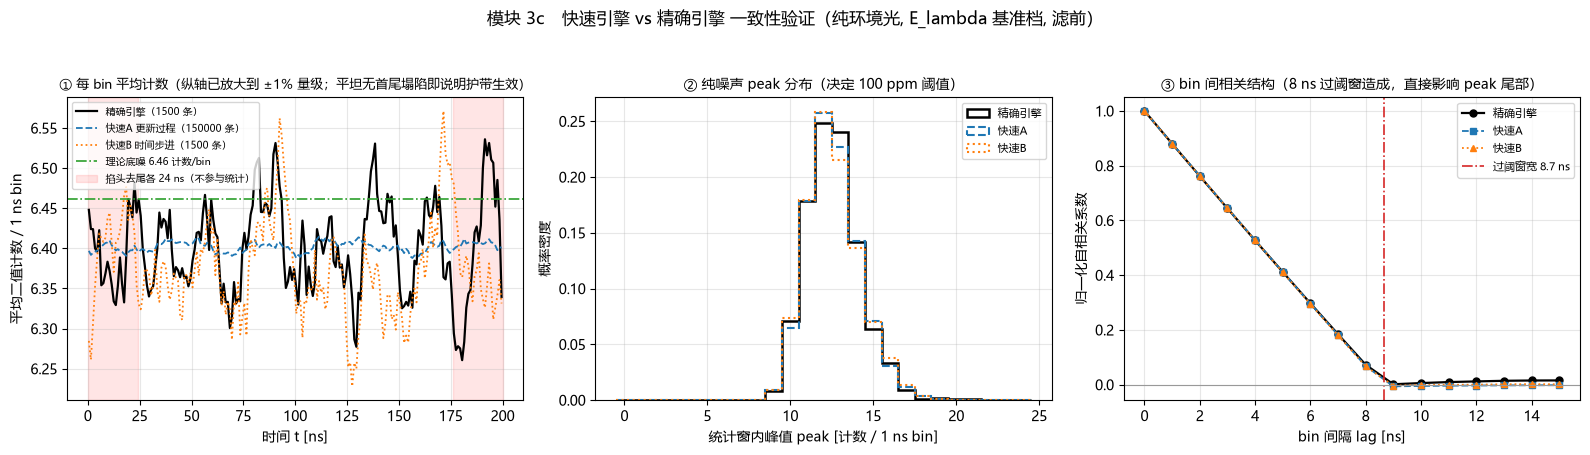

In [7]:
# ---- 一致性验证：纯环境光 ----
_N_EX, _N_FAST = 1500, 150_000
_rng_v = np.random.default_rng(PARAMS["hist"]["seed"] + 901)
_r_det_v = R_AMB_BASE * PDE
_f_zero = np.zeros(N_PIX_MACRO * 4)          # 纯噪声：收集比例全 0（N_shots=4）
_zero_rate = np.zeros_like(TF_GEN)

_t = time.time()
h_ex = macro_hist_exact(_N_EX, _f_zero, _zero_rate, R_AMB_BASE, TF_GEN, CENTERS,
                        _rng_v, boost=0.0)
_t_ex = time.time() - _t

_t = time.time()
h_fa = noise_macro_hist_fast(_N_FAST, N_PIX_MACRO*4, _r_det_v,
                             np.random.default_rng(PARAMS["hist"]["seed"] + 902))
_t_fa = time.time() - _t

_t = time.time()
h_fb = binary_macro_stepping(_N_EX, _f_zero, _zero_rate, TF_GEN, R_AMB_BASE, CENTERS,
                             np.random.default_rng(PARAMS["hist"]["seed"] + 903), boost=0.0)
_t_fb = time.time() - _t

def _stat(h):
    a = h[:, I_STAT0:I_STAT1].astype(float)
    pk = a.max(axis=1)
    return dict(mean=a.mean(), var=a.var(), pk=pk,
                corr=np.corrcoef(a[:, :-1].ravel(), a[:, 1:].ravel())[0, 1])

s_ex, s_fa, s_fb = _stat(h_ex), _stat(h_fa), _stat(h_fb)
mu_win_theory = (1.0 - np.exp(-_r_det_v * T_OVER)) * N_PIX_MACRO * 4

print("="*90)
print(f"【一致性验证】纯环境光，N_shots=4（27×4={N_PIX_MACRO*4} 条轨迹），统计窗 "
      f"[{TRIM_NS:.0f}, {WIN_HI_NS-TRIM_NS:.0f}] ns 共 {N_STAT} bin")
print(f"  理论底噪 = [1-exp(-r_det·T_OVER)]×27×4 = {mu_win_theory:.4f} 计数/bin")
print(f"  {'引擎':<22}{'条数':>8}{'每bin均值':>11}{'每bin方差':>11}{'peak均值':>10}"
      f"{'peak标准差':>11}{'相邻bin相关':>12}{'用时[s]':>9}")
for tag, s, n, tt in [("精确 spad_binary_trace", s_ex, _N_EX, _t_ex),
                      ("快速A 更新过程", s_fa, _N_FAST, _t_fa),
                      ("快速B 时间步进", s_fb, _N_EX, _t_fb)]:
    print(f"  {tag:<22}{n:>8d}{s['mean']:>11.4f}{s['var']:>11.4f}{s['pk'].mean():>10.4f}"
          f"{s['pk'].std():>11.4f}{s['corr']:>12.4f}{tt:>9.1f}")
print(f"  提速：快速A = {(_t_ex/_N_EX)/(_t_fa/_N_FAST):.0f}×，"
      f"快速B = {(_t_ex/_N_EX)/(_t_fb/_N_EX):.1f}×")

# ---- 一致性验证：带信号（快速B vs 精确）----
_BOOST_V = 3e-3          # 让峰值落在未饱和区，便于比较分布
_f_arr_v = np.tile(F_VALS, 4)
_N_SV = 1000
_t = time.time()
hs_ex = macro_hist_exact(_N_SV, _f_arr_v, R_SIG_UNIT_GEN, R_AMB_BASE, TF_GEN, CENTERS,
                         np.random.default_rng(PARAMS["hist"]["seed"] + 911), boost=_BOOST_V)
_ts_ex = time.time() - _t
_t = time.time()
hs_fb = binary_macro_stepping(_N_SV, _f_arr_v, R_SIG_UNIT_GEN, TF_GEN, R_AMB_BASE, CENTERS,
                              np.random.default_rng(PARAMS["hist"]["seed"] + 912), boost=_BOOST_V)
_ts_fb = time.time() - _t
_sig_sl = slice(int(T0_SIG_NS - SIG_PRE_NS), int(T0_SIG_NS + SIG_POST_NS))
pk_se, pk_sf = hs_ex[:, _sig_sl].max(axis=1), hs_fb[:, _sig_sl].max(axis=1)
_se = np.sqrt(pk_se.var()/_N_SV + pk_sf.var()/_N_SV)
print(f"\n  带信号（boost={_BOOST_V:g}, N_shots=4, 信号窗 bin "
      f"{_sig_sl.start}–{_sig_sl.stop-1}，各 {_N_SV} 条）：")
print(f"    精确  峰值 {pk_se.mean():.3f} ± {pk_se.std():.3f}（{_ts_ex:.1f} s）")
print(f"    快速B 峰值 {pk_sf.mean():.3f} ± {pk_sf.std():.3f}（{_ts_fb:.1f} s）")
print(f"    峰值均值之差 = {abs(pk_se.mean()-pk_sf.mean()):.3f}，两样本标准误 = {_se:.3f} "
      f"（{abs(pk_se.mean()-pk_sf.mean())/max(_se,1e-9):.1f}σ，<2σ 视为一致）")

# ---- 验证图 ----
fig, ax = plt.subplots(1, 3, figsize=(16, 4.6))

ax[0].plot(TC_NS, h_ex.mean(axis=0), color="k", lw=1.6, label=f"精确引擎（{_N_EX} 条）")
ax[0].plot(TC_NS, h_fa.mean(axis=0), color="tab:blue", lw=1.3, ls="--",
           label=f"快速A 更新过程（{_N_FAST} 条）")
ax[0].plot(TC_NS, h_fb.mean(axis=0), color="tab:orange", lw=1.3, ls=":",
           label=f"快速B 时间步进（{_N_EX} 条）")
ax[0].axhline(mu_win_theory, color="tab:green", lw=1.2, ls="-.",
              label=f"理论底噪 {mu_win_theory:.2f} 计数/bin")
ax[0].axvspan(0, TRIM_NS, color="red", alpha=0.10)
ax[0].axvspan(WIN_HI_NS-TRIM_NS, WIN_HI_NS, color="red", alpha=0.10,
              label=f"掐头去尾各 {TRIM_NS:.0f} ns（不参与统计）")
ax[0].set_xlabel("时间 t [ns]"); ax[0].set_ylabel("平均二值计数 / 1 ns bin")
ax[0].set_title("① 每 bin 平均计数（纵轴已放大到 ±1% 量级；平坦无首尾塌陷即说明护带生效）",
                fontsize=9.5)
ax[0].legend(fontsize=7.5); ax[0].grid(alpha=0.3)

_bmax = int(max(s_ex["pk"].max(), s_fa["pk"].max(), s_fb["pk"].max())) + 2
_bins = np.arange(-0.5, _bmax + 0.5)
ax[1].hist(s_ex["pk"], bins=_bins, density=True, histtype="step", lw=1.8,
           color="k", label="精确引擎")
ax[1].hist(s_fa["pk"], bins=_bins, density=True, histtype="step", lw=1.5,
           color="tab:blue", ls="--", label="快速A")
ax[1].hist(s_fb["pk"], bins=_bins, density=True, histtype="step", lw=1.5,
           color="tab:orange", ls=":", label="快速B")
ax[1].set_xlabel("统计窗内峰值 peak [计数 / 1 ns bin]"); ax[1].set_ylabel("概率密度")
ax[1].set_title("② 纯噪声 peak 分布（决定 100 ppm 阈值）", fontsize=10)
ax[1].legend(fontsize=8); ax[1].grid(alpha=0.3)

_lags = np.arange(0, 16)
def _acf(h):
    a = h[:, I_STAT0:I_STAT1].astype(float)
    a = a - a.mean()
    v = (a * a).mean()
    return np.array([(a[:, :a.shape[1]-L] * a[:, L:]).mean() / v for L in _lags])
ax[2].plot(_lags, _acf(h_ex), "o-", color="k", lw=1.6, ms=5, label="精确引擎")
ax[2].plot(_lags, _acf(h_fa), "s--", color="tab:blue", lw=1.3, ms=4, label="快速A")
ax[2].plot(_lags, _acf(h_fb), "^:", color="tab:orange", lw=1.3, ms=4, label="快速B")
ax[2].axvline(T_OVER*1e9, color="tab:red", ls="-.", lw=1.2,
              label=f"过阈窗宽 {T_OVER*1e9:.1f} ns")
ax[2].axhline(0, color="0.6", lw=0.8)
ax[2].set_xlabel("bin 间隔 lag [ns]"); ax[2].set_ylabel("归一化自相关系数")
ax[2].set_title("③ bin 间相关结构（8 ns 过阈窗造成，直接影响 peak 尾部）", fontsize=10)
ax[2].legend(fontsize=8); ax[2].grid(alpha=0.3)

plt.suptitle("模块 3c　快速引擎 vs 精确引擎 一致性验证（纯环境光, E_lambda 基准档, 滤前）",
             fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.savefig("pod_esti_engine_check.png", dpi=110, bbox_inches="tight")
plt.show()


## 模块 4 — 纯噪声波形长什么样

先看一条具体的纯环境光波形，直观理解「掐头去尾」以及 `noise` / `peak` 两个统计量的定义。


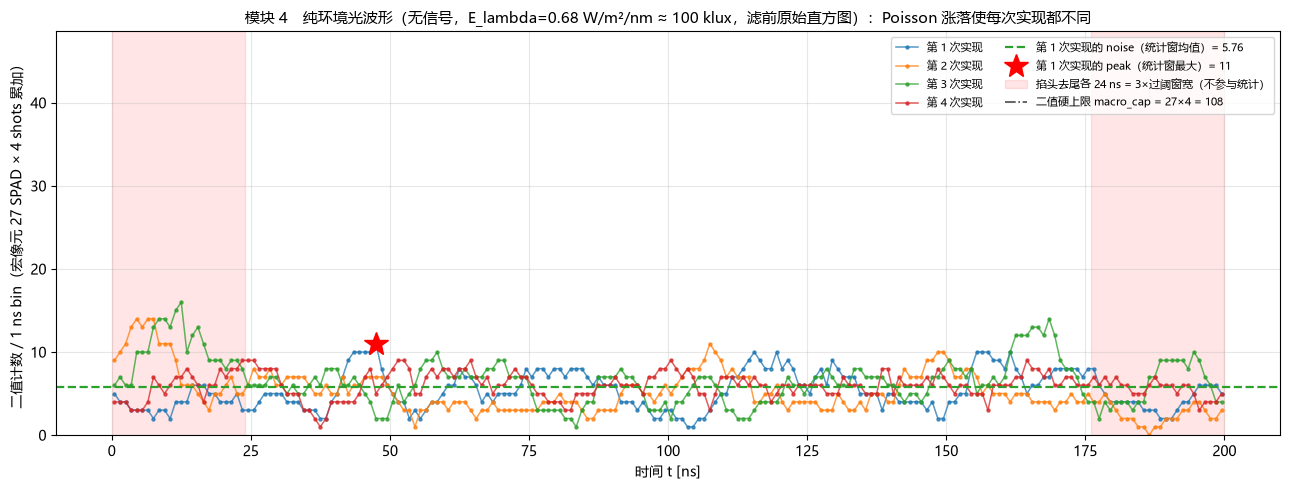

6 次实现的 (noise, peak)：
  实现 1: noise =  5.763 计数/bin,  peak =  11 计数 @ t = 47.5 ns
  实现 2: noise =  5.138 计数/bin,  peak =  11 计数 @ t = 107.5 ns
  实现 3: noise =  6.178 计数/bin,  peak =  14 计数 @ t = 168.5 ns
  实现 4: noise =  6.105 计数/bin,  peak =   9 计数 @ t = 24.5 ns
  实现 5: noise =  7.283 计数/bin,  peak =  13 计数 @ t = 56.5 ns
  实现 6: noise =  5.625 计数/bin,  peak =  11 计数 @ t = 169.5 ns


In [8]:
_rng_d = np.random.default_rng(PARAMS["hist"]["seed"] + 77)
_demo = noise_macro_hist_fast(6, N_PIX_MACRO*4, R_AMB_BASE*PDE, _rng_d)

fig, ax = plt.subplots(figsize=(13, 5))
for i in range(4):
    ax.plot(TC_NS, _demo[i], lw=1.1, marker="o", ms=2.2, alpha=0.75,
            label=f"第 {i+1} 次实现")
w0 = _demo[0, I_STAT0:I_STAT1]
ax.axhline(w0.mean(), color="tab:green", ls="--", lw=1.6,
           label=f"第 1 次实现的 noise（统计窗均值）= {w0.mean():.2f}")
ax.plot(TC_NS[I_STAT0 + int(w0.argmax())], w0.max(), "*", color="red", ms=18,
        label=f"第 1 次实现的 peak（统计窗最大）= {w0.max():.0f}")
ax.axvspan(0, TRIM_NS, color="red", alpha=0.10)
ax.axvspan(WIN_HI_NS-TRIM_NS, WIN_HI_NS, color="red", alpha=0.10,
           label=f"掐头去尾各 {TRIM_NS:.0f} ns = 3×过阈窗宽（不参与统计）")
ax.axhline(N_PIX_MACRO*4, color="k", ls="-.", lw=1.2, alpha=0.7,
           label=f"二值硬上限 macro_cap = 27×4 = {N_PIX_MACRO*4}")
ax.set_xlabel("时间 t [ns]")
ax.set_ylabel("二值计数 / 1 ns bin（宏像元 27 SPAD × 4 shots 累加）")
ax.set_title(f"模块 4　纯环境光波形（无信号，E_lambda={PARAMS['ambient']['E_lambda']} W/m²/nm ≈ 100 klux，"
             f"滤前原始直方图）：Poisson 涨落使每次实现都不同", fontsize=11)
ax.legend(fontsize=8, loc="upper right", ncol=2)
ax.set_ylim(0, max(N_PIX_MACRO*4*0.45, _demo.max()*1.45))
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("pod_esti_noise_waveform.png", dpi=110, bbox_inches="tight")
plt.show()

print(f"6 次实现的 (noise, peak)：")
for i in range(6):
    w = _demo[i, I_STAT0:I_STAT1]
    print(f"  实现 {i+1}: noise = {w.mean():6.3f} 计数/bin,  peak = {w.max():3.0f} 计数 "
          f"@ t = {TC_NS[I_STAT0+int(w.argmax())]:.1f} ns")


## 模块 5 —— 第 1 步：噪声强度扫描 → noise–peak 曲线

扫环境光谱辐照度 `E_lambda` 的倍数（基准 0.68 W/m²/nm ≈ 100 klux 白天）。
每档跑 `N_MC_NOISE` 条纯噪声波形，每条记 `noise`（统计窗内 152 个 bin 的均值）
与 `peak`（统计窗内最大 bin 计数）。

**理论对照**（下图绿虚线）：单 SPAD 单 shot 点亮某个 bin 的概率

$$p_\mathrm{bin} = 1-e^{-r_\mathrm{det}\cdot T_\mathrm{OVER}},\qquad
r_\mathrm{det}=r_\mathrm{amb}\cdot \mathrm{PDE_{max}}$$

故每 bin 计数服从 $\mathrm{Binomial}(n_\mathrm{tr},\,p_\mathrm{bin})$，均值 $n_\mathrm{tr}\,p_\mathrm{bin}$，
其中 $n_\mathrm{tr}=27\times N_\mathrm{shots}$。

> ⚠️ **坑 1**：注意指数里是 **`T_OVER`（8 ns）而不是 bin 宽（1 ns）**。8 ns 的过阈窗会把一次雪崩"涂"到约 8 个 bin 上，
> 用 `r_det·bin_width` 估底噪会**低估约 8 倍**——这是本项目历史上踩过的坑。
>
> ⚠️ **坑 2**：这条理论线本身也只是**低速率近似**。它默认雪崩是速率 `r_det` 的 Poisson 过程，
> 但 RC 恢复带来 8 ns 计数死区，雪崩不可能挨得太近。当 `r_det·T_OVER` 不再远小于 1 时
> （下表 `E_λ×10` 档），实测底噪会**低于**理论线约 5–6%，这是真实的死区抑制，不是 bug。
> 所以**阈值一律以 MC 实测为准，理论线只用于量级核对。**


In [9]:
def run_noise_scan(n_shots, amb_mults, n_mc, chunk, seed0=2000):
    """对一组环境光倍数跑纯噪声 MC。返回 dict：每档的 noise 均值、peak 数组等。"""
    n_tr = N_PIX_MACRO * n_shots
    res = {"amb_mult": np.array(amb_mults, float), "n_tr": n_tr, "n_shots": n_shots,
           "noise_mean": [], "noise_all": [], "peak_all": [], "p_bin": [], "r_det": []}
    for k, mult in enumerate(amb_mults):
        r_det = R_AMB_BASE * mult * PDE
        t0 = time.time()
        noises, peaks = [], []
        for s in range(0, n_mc, chunk):
            m = min(chunk, n_mc - s)
            h = noise_macro_hist_fast(m, n_tr, r_det,
                                      np.random.default_rng(seed0 + 1000*k + s))
            a = h[:, I_STAT0:I_STAT1]
            noises.append(a.mean(axis=1)); peaks.append(a.max(axis=1))
        noise = np.concatenate(noises); peak = np.concatenate(peaks).astype(np.int32)
        p_bin = 1.0 - np.exp(-r_det * T_OVER)
        res["noise_all"].append(noise); res["peak_all"].append(peak)
        res["noise_mean"].append(noise.mean()); res["p_bin"].append(p_bin)
        res["r_det"].append(r_det)
        print(f"  [N_shots={n_shots}] E_lambda×{mult:<6g} r_det={r_det:.3e} cps  "
              f"noise={noise.mean():7.3f}（理论 {n_tr*p_bin:7.3f}）  "
              f"peak 均值={peak.mean():6.2f} 中位={np.median(peak):5.1f} "
              f"最大={peak.max():4d}/{n_tr}  [{time.time()-t0:.0f} s]")
    for key in ["noise_mean", "p_bin", "r_det"]:
        res[key] = np.array(res[key])
    return res

# ---- 跑（带缓存）----
_need = True
if USE_CACHE and os.path.exists(CACHE_NOISE):
    _z = np.load(CACHE_NOISE, allow_pickle=True)
    if (list(_z["amb_mults"]) == list(AMB_MULTS) and int(_z["n_mc"]) == N_MC_NOISE
            and list(_z["n_shots_list"]) == list(N_SHOTS_LIST)):
        NOISE_RES = _z["res"].item(); _need = False
        print(f"已从缓存 {CACHE_NOISE} 载入纯噪声 MC 结果（{N_MC_NOISE:,} 条/档）")
if _need:
    print(f"纯噪声 MC：{len(AMB_MULTS)} 个环境档 × {len(N_SHOTS_LIST)} 种 N_shots × "
          f"{N_MC_NOISE:,} 条（快速引擎 A）")
    NOISE_RES = {}
    _tall = time.time()
    for _ns in N_SHOTS_LIST:
        NOISE_RES[_ns] = run_noise_scan(_ns, AMB_MULTS, N_MC_NOISE, MC_CHUNK)
    print(f"总用时 {time.time()-_tall:.0f} s")
    np.savez_compressed(CACHE_NOISE, res=np.array(NOISE_RES, dtype=object),
                        amb_mults=np.array(AMB_MULTS), n_mc=N_MC_NOISE,
                        n_shots_list=np.array(N_SHOTS_LIST))
    print(f"已写入缓存 {CACHE_NOISE}")


已从缓存 pod_esti_cache_noise.npz 载入纯噪声 MC 结果（1,000,000 条/档）


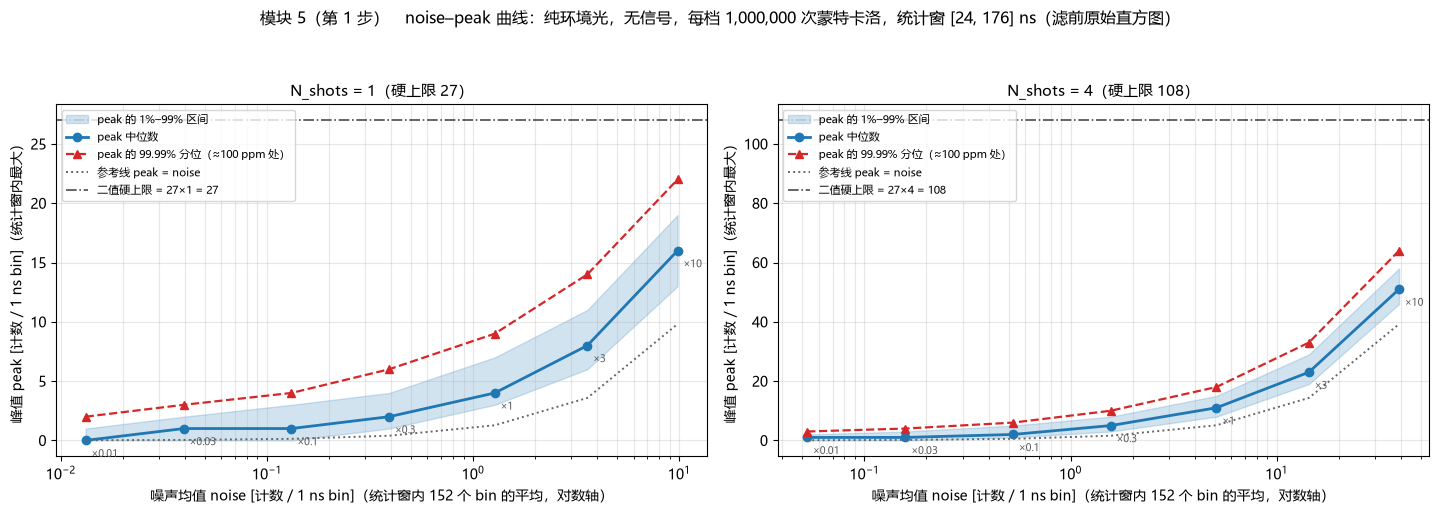

 N_shots    E_λ倍数   ≈klux   r_det[cps]    noise   理论noise   σ_bin   peak中位 peak99.99%    上限
       1     0.01       1    6.107e+04    0.013     0.013   0.115      0.0        2.0    27
       1     0.03       3    1.832e+05    0.040     0.040   0.199      1.0        3.0    27
       1      0.1      10    6.107e+05    0.132     0.132   0.362      1.0        4.0    27
       1      0.3      30    1.832e+06    0.392     0.393   0.622      2.0        6.0    27
       1        1     100    6.107e+06    1.274     1.287   1.107      4.0        9.0    27
       1        3     300    1.832e+07    3.582     3.681   1.783      8.0       14.0    27
       1       10    1000    6.107e+07    9.807    10.436   2.530     16.0       22.0    27
       4     0.01       1    6.107e+04    0.053     0.053   0.230      1.0        3.0   108
       4     0.03       3    1.832e+05    0.158     0.158   0.397      1.0        4.0   108
       4      0.1      10    6.107e+05    0.526     0.526   0.724      2.0      

In [10]:
# ---- noise–peak 曲线 ----
fig, ax = plt.subplots(1, 2, figsize=(14.5, 5.2))
_cols = plt.cm.viridis(np.linspace(0.1, 0.9, len(AMB_MULTS)))

for j, n_shots in enumerate(N_SHOTS_LIST):
    R = NOISE_RES[n_shots]
    a = ax[j]
    nm = R["noise_mean"]
    pk_med = np.array([np.median(p) for p in R["peak_all"]])
    pk_lo  = np.array([np.percentile(p, 1) for p in R["peak_all"]])
    pk_hi  = np.array([np.percentile(p, 99) for p in R["peak_all"]])
    pk_max = np.array([np.percentile(p, 100*(1-1e-4)) for p in R["peak_all"]])
    a.fill_between(nm, pk_lo, pk_hi, color="tab:blue", alpha=0.20,
                   label="peak 的 1%–99% 区间")
    a.plot(nm, pk_med, "o-", color="tab:blue", lw=2.0, ms=6, label="peak 中位数")
    a.plot(nm, pk_max, "^--", color="tab:red", lw=1.6, ms=6,
           label="peak 的 99.99% 分位（≈100 ppm 处）")
    a.plot(nm, nm, ":", color="0.4", lw=1.4, label="参考线 peak = noise")
    a.axhline(R["n_tr"], color="k", ls="-.", lw=1.2, alpha=0.7,
              label=f"二值硬上限 = 27×{n_shots} = {R['n_tr']}")
    for k, mult in enumerate(AMB_MULTS):
        a.annotate(f"×{mult:g}", (nm[k], pk_med[k]), textcoords="offset points",
                   xytext=(4, -12), fontsize=7.5, color="0.35")
    a.set_xscale("log")
    a.set_xlabel("噪声均值 noise [计数 / 1 ns bin]（统计窗内 152 个 bin 的平均，对数轴）")
    a.set_ylabel("峰值 peak [计数 / 1 ns bin]（统计窗内最大）")
    a.set_title(f"N_shots = {n_shots}（硬上限 {R['n_tr']}）", fontsize=11)
    a.legend(fontsize=8, loc="upper left"); a.grid(alpha=0.3, which="both")

plt.suptitle(f"模块 5（第 1 步）　noise–peak 曲线：纯环境光，无信号，每档 {N_MC_NOISE:,} 次蒙特卡洛，"
             f"统计窗 [{TRIM_NS:.0f}, {WIN_HI_NS-TRIM_NS:.0f}] ns（滤前原始直方图）", fontsize=11.5)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig("pod_esti_noise_peak.png", dpi=110, bbox_inches="tight")
plt.show()

print("="*100)
print(f"{'N_shots':>8}{'E_λ倍数':>9}{'≈klux':>8}{'r_det[cps]':>13}{'noise':>9}"
      f"{'理论noise':>10}{'σ_bin':>8}{'peak中位':>9}{'peak99.99%':>11}{'上限':>6}")
for n_shots in N_SHOTS_LIST:
    R = NOISE_RES[n_shots]
    for k, mult in enumerate(AMB_MULTS):
        pk = R["peak_all"][k]
        sig_bin = np.sqrt(R["n_tr"] * R["p_bin"][k] * (1 - R["p_bin"][k]))
        print(f"{n_shots:>8d}{mult:>9g}{100*mult:>8.0f}{R['r_det'][k]:>13.3e}"
              f"{R['noise_mean'][k]:>9.3f}{R['n_tr']*R['p_bin'][k]:>10.3f}{sig_bin:>8.3f}"
              f"{np.median(pk):>9.1f}{np.percentile(pk,99.99):>11.1f}{R['n_tr']:>6d}")
print("注：≈klux 按 E_lambda 与照度近似线性外推（基准 0.68 W/m²/nm ≈ 100 klux），仅供量级参考。")


## 模块 6 —— 第 2 步：100 ppm 噪点率对应的检测阈值

**噪点率（窗口级虚警率）定义**（与用户口径一致）：

> 一次测量（N_shots 发累加）中，**统计窗内 152 个 bin 的最大值 `peak` ≥ 阈值 `T`** 的概率。
> 目标：**< 100 ppm = 1e-4**。

因为 `peak` 取整数值，阈值只能取整数，实际达到的 FAR 会**跳跃式**低于目标值。
取 **满足 `P(peak ≥ T) < 1e-4` 的最小整数 T**。

### 为什么必须用蒙特卡洛，不能套解析式

一个自然的想法是：每 bin 计数 ~ $\mathrm{Binomial}(n_\mathrm{tr}, p_\mathrm{bin})$，
再按「152 个 bin 相互独立」算窗口级 FAR $=1-(1-a_\mathrm{bin})^{152}$。**这个式子会给出偏保守（偏高）的阈值**，原因是：

- 8 ns 的过阈窗让**相邻约 8 个 bin 强相关**（模块 3c 图③ 实测相邻 bin 相关系数 ≈ 0.87），
  等效独立 bin 数远少于 152，真实的窗口级 FAR 因此**低于**独立假设的预测；
- 二值模型每 bin 有**硬上限** $n_\mathrm{tr}$，分布不是 Poisson。

下面同时给出「MC 实测阈值」与「独立 Binomial 解析阈值」，可以直接看到后者保守多少。


 N_shots    E_λ倍数    noise   σ_bin  noise+3σ    T(MC实测)      FAR@T    FAR@T-1    T(独立Binom)    上限
       1     0.01    0.013   0.115     0.358          3   2.30e-05   3.01e-03             3    27
       1     0.03    0.040   0.199     0.636          4   5.00e-06   4.38e-04             4    27
       1      0.1    0.132   0.362     1.217          5   1.20e-05   5.26e-04             5    27
       1      0.3    0.392   0.622     2.258          7   1.40e-05   1.65e-04             7    27
       1        1    1.274   1.107     4.596         10   3.40e-05   2.51e-04            10    27
       1        3    3.582   1.783     8.931         15   3.30e-05   2.07e-04            15    27
       1       10    9.807   2.530    17.398         23   2.50e-05   2.21e-04            24    27
       4     0.01    0.053   0.230     0.742          4   1.50e-05   1.07e-03             4   108
       4     0.03    0.158   0.397     1.350          5   4.80e-05   1.36e-03             6   108
       4      0.1   

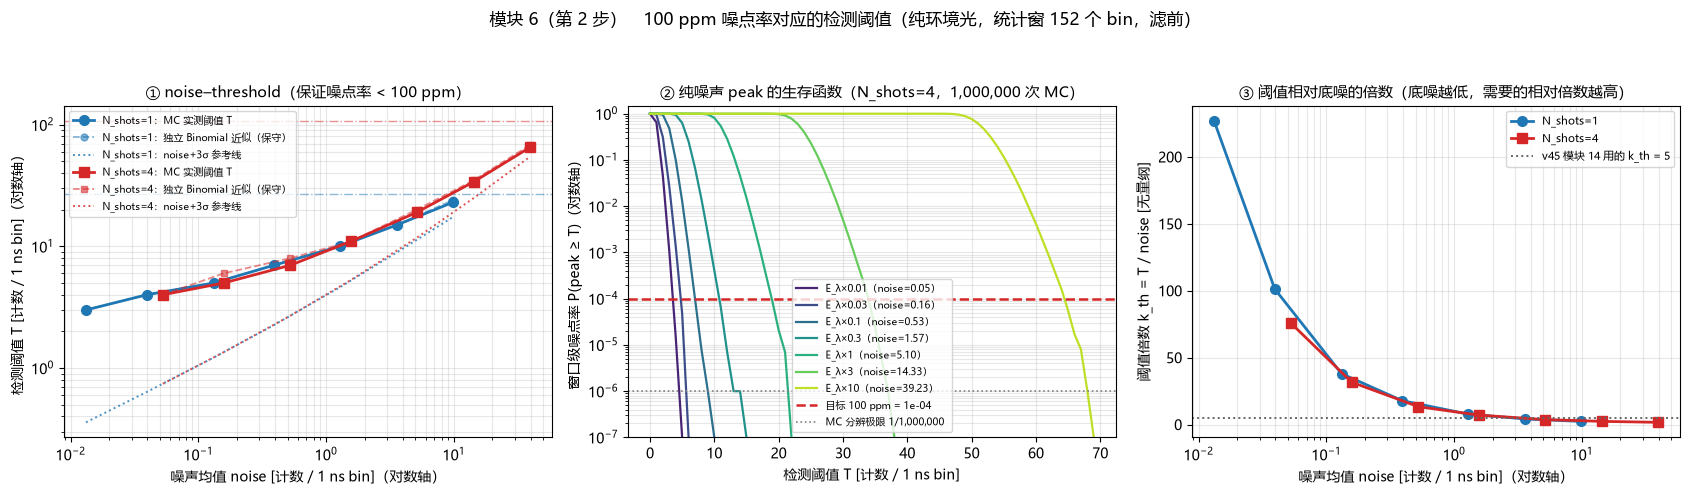

In [11]:
def far_threshold_from_peaks(peaks, target_far):
    """由 peak 样本求满足 P(peak ≥ T) < target_far 的最小整数 T，并返回该 T 处的实测 FAR。
    全程用【整数计数】比较（n_ge < target_far·n），避免 1e-4 与 2/20000 这类浮点边界误判。"""
    pmax = int(peaks.max())
    n = peaks.size
    cnt = np.bincount(peaks, minlength=pmax + 2)
    n_ge = np.concatenate([[n], n - np.cumsum(cnt)[:-1]])   # n_ge[T] = #{peak >= T}
    lim = target_far * n                                    # 允许的最大越阈次数（不含）
    ok = np.where(n_ge < lim)[0]
    sf = n_ge / n
    if ok.size == 0:
        return pmax + 1, 0.0, sf
    T = int(ok[0])
    return T, float(sf[T]), sf


def far_threshold_binom_indep(n_tr, p_bin, n_bins, target_far):
    """独立 Binomial 近似阈值（保守对照）：a_bin = 1-(1-FAR)^(1/n_bins)，反解最小 T。"""
    a_bin = 1.0 - (1.0 - target_far) ** (1.0 / n_bins)
    T = 0
    while T <= n_tr and _binom.sf(T - 1, n_tr, p_bin) > a_bin:
        T += 1
    return T, a_bin


THRESH = {}
print("="*106)
print(f"{'N_shots':>8}{'E_λ倍数':>9}{'noise':>9}{'σ_bin':>8}{'noise+3σ':>10}"
      f"{'T(MC实测)':>11}{'FAR@T':>11}{'FAR@T-1':>11}{'T(独立Binom)':>14}{'上限':>6}")
for n_shots in N_SHOTS_LIST:
    R = NOISE_RES[n_shots]
    rec = {"T": [], "far": [], "T_indep": [], "sigma_bin": [], "noise": R["noise_mean"]}
    for k, mult in enumerate(AMB_MULTS):
        pk = R["peak_all"][k]
        T, far, sf = far_threshold_from_peaks(pk, TARGET_FAR)
        far_m1 = float(sf[T-1]) if T-1 < sf.size else 1.0
        Ti, a_bin = far_threshold_binom_indep(R["n_tr"], R["p_bin"][k], N_STAT, TARGET_FAR)
        sig_bin = np.sqrt(R["n_tr"] * R["p_bin"][k] * (1 - R["p_bin"][k]))
        rec["T"].append(T); rec["far"].append(far); rec["T_indep"].append(Ti)
        rec["sigma_bin"].append(sig_bin)
        _flag = "  ← 已顶到硬上限，该档无法满足 100 ppm" if T > R["n_tr"] else ""
        print(f"{n_shots:>8d}{mult:>9g}{R['noise_mean'][k]:>9.3f}{sig_bin:>8.3f}"
              f"{R['noise_mean'][k]+3*sig_bin:>10.3f}{T:>11d}{far:>11.2e}{far_m1:>11.2e}"
              f"{Ti:>14d}{R['n_tr']:>6d}{_flag}")
    for key in rec:
        rec[key] = np.asarray(rec[key])
    THRESH[n_shots] = rec

# ---- 绘图 ----
fig, ax = plt.subplots(1, 3, figsize=(17, 5.0))

# 图① noise–threshold
for n_shots, mk, cc in zip(N_SHOTS_LIST, ["o", "s"], ["tab:blue", "tab:red"]):
    R, Tr = NOISE_RES[n_shots], THRESH[n_shots]
    ax[0].plot(Tr["noise"], Tr["T"], mk + "-", color=cc, lw=2.0, ms=7,
               label=f"N_shots={n_shots}：MC 实测阈值 T")
    ax[0].plot(Tr["noise"], Tr["T_indep"], mk + "--", color=cc, lw=1.3, ms=5, alpha=0.55,
               label=f"N_shots={n_shots}：独立 Binomial 近似（保守）")
    ax[0].plot(Tr["noise"], Tr["noise"] + 3*Tr["sigma_bin"], ":", color=cc, lw=1.4,
               alpha=0.8, label=f"N_shots={n_shots}：noise+3σ 参考线")
    ax[0].axhline(R["n_tr"], color=cc, ls="-.", lw=1.0, alpha=0.5)
ax[0].set_xscale("log"); ax[0].set_yscale("log")
ax[0].set_xlabel("噪声均值 noise [计数 / 1 ns bin]（对数轴）")
ax[0].set_ylabel("检测阈值 T [计数 / 1 ns bin]（对数轴）")
ax[0].set_title(f"① noise–threshold（保证噪点率 < {TARGET_FAR*1e6:.0f} ppm）", fontsize=10.5)
ax[0].legend(fontsize=7.5, loc="upper left"); ax[0].grid(alpha=0.3, which="both")

# 图② peak 生存函数（尾部）
_ns_sf = N_SHOTS_LIST[-1]
R = NOISE_RES[_ns_sf]
for k, mult in enumerate(AMB_MULTS):
    pk = R["peak_all"][k]
    Ts = np.arange(0, int(pk.max()) + 2)
    sf = np.array([(pk >= T).mean() for T in Ts])
    ax[1].semilogy(Ts, np.maximum(sf, 1e-7), "-", color=_cols[k], lw=1.6,
                   label=f"E_λ×{mult:g}（noise={R['noise_mean'][k]:.2f}）")
ax[1].axhline(TARGET_FAR, color="tab:red", ls="--", lw=1.8,
              label=f"目标 {TARGET_FAR*1e6:.0f} ppm = {TARGET_FAR:.0e}")
ax[1].axhline(1.0/N_MC_NOISE, color="0.5", ls=":", lw=1.2,
              label=f"MC 分辨极限 1/{N_MC_NOISE:,} ")
ax[1].set_ylim(1e-7, 1.5)
ax[1].set_xlabel("检测阈值 T [计数 / 1 ns bin]")
ax[1].set_ylabel("窗口级噪点率 P(peak ≥ T)（对数轴）")
ax[1].set_title(f"② 纯噪声 peak 的生存函数（N_shots={_ns_sf}，{N_MC_NOISE:,} 次 MC）",
                fontsize=10.5)
ax[1].legend(fontsize=7.5); ax[1].grid(alpha=0.3, which="both")

# 图③ 阈值相对底噪的倍数 k_th = T / noise
for n_shots, mk, cc in zip(N_SHOTS_LIST, ["o", "s"], ["tab:blue", "tab:red"]):
    Tr = THRESH[n_shots]
    ax[2].plot(Tr["noise"], Tr["T"] / np.maximum(Tr["noise"], 1e-9), mk + "-",
               color=cc, lw=2.0, ms=7, label=f"N_shots={n_shots}")
ax[2].axhline(5.0, color="0.4", ls=":", lw=1.4, label="v45 模块 14 用的 k_th = 5")
ax[2].set_xscale("log")
ax[2].set_xlabel("噪声均值 noise [计数 / 1 ns bin]（对数轴）")
ax[2].set_ylabel("阈值倍数 k_th = T / noise [无量纲]")
ax[2].set_title("③ 阈值相对底噪的倍数（底噪越低，需要的相对倍数越高）", fontsize=10.5)
ax[2].legend(fontsize=8); ax[2].grid(alpha=0.3, which="both")

plt.suptitle(f"模块 6（第 2 步）　100 ppm 噪点率对应的检测阈值（纯环境光，统计窗 {N_STAT} 个 bin，滤前）",
             fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig("pod_esti_threshold.png", dpi=110, bbox_inches="tight")
plt.show()


## 模块 7 —— 第 3 步：信号能量扫描 → PoD 曲线

### 起点：峰值落在 `noise + 3σ` 的信号

`σ` 取每 bin 计数的 Binomial 标准差 $\sigma_\mathrm{bin}=\sqrt{n_\mathrm{tr}\,p_\mathrm{bin}(1-p_\mathrm{bin})}$。
先用粗扫找到「信号峰均值 ≈ noise + 3σ」的能量倍数 `boost`，作为主扫描的下界。

### 能量的度量

`boost` 是对**回波光子率**的线性倍数。由于回波率对发射功率线性，
在固定 ρ = 0.10、D = 15 m 的前提下，它等价于把**单脉冲发射能量**乘以同样的倍数：

$$E_\mathrm{pulse}^\mathrm{eff} = E_\mathrm{pulse}^\mathrm{base}\times \mathrm{boost},
\qquad E_\mathrm{pulse}^\mathrm{base}=\int P(t)\,\mathrm{d}t
= \frac{P_\mathrm{peak}}{s_\mathrm{peak}}\,(\tau_f-\tau_r)\approx 799\ \mathrm{nJ}$$

其中 $s_\mathrm{peak}=e^{-t_p/\tau_f}-e^{-t_p/\tau_r}\approx 0.353$ 是双指数形状函数的峰值
（因为 `pulse_temporal` 把形状归一到峰值 = `P_peak`）。

> ⚠️ **这个折算固定了 ρ 与 D。** `boost` 同样可以解释成反射率变化（$\rho_\mathrm{eff}=0.10\times\mathrm{boost}$）
> 或距离变化，三者对回波强度的作用是等价的。表格里三种度量都会给出。

### PoD 判据

**峰值 ≥ T 且峰位落在信号窗内**，信号窗取 $[\,t_\mathrm{ToF}-3\ \mathrm{ns},\ t_\mathrm{ToF}+12\ \mathrm{ns}\,]$
（覆盖 8 ns 过阈窗 + 余量）。因为阈值已保证窗外噪声超阈的概率 < 1e-4，
所以直接用「信号窗内最大 bin ≥ T」即可，与严格判据的差别 < 1e-4。

**计算量优化**：PoD 的 MC 只需要信号窗那十几个 bin，所以时间步进只跑
$[\,t_\mathrm{ToF}-60\ \mathrm{ns},\ t_\mathrm{ToF}+12\ \mathrm{ns}\,]$，
其中前 57 ns 只作暖机（$\gg 3\tau_\mathrm{RC}+T_\mathrm{OVER}\approx 34$ ns），不参与统计。这样比跑满 200 ns 快约 4 倍。


In [12]:
# ---- PoD 专用的子窗（只算信号窗那几个 bin，其余只作暖机）----
POD_T_LO = T0_SIG - POD_WARM_NS * 1e-9
POD_T_HI = T0_SIG + SIG_POST_NS * 1e-9
TF_POD   = np.arange(POD_T_LO, POD_T_HI, DT_FINE)
_sigmask = (TC_NS >= T0_SIG_NS - SIG_PRE_NS) & (TC_NS <= T0_SIG_NS + SIG_POST_NS)
IDX_SIG  = np.where(_sigmask)[0]
CENTERS_SIG = CENTERS[IDX_SIG]
R_SIG_UNIT_POD = signal_photon_rate_fine(ECHO0, 1.0, TF_POD)

print(f"PoD 子窗：{POD_T_LO*1e9:.1f} – {POD_T_HI*1e9:.1f} ns，{TF_POD.size} 个细网格步"
      f"（跑满 200 ns 需 {TF_GEN.size} 步，提速 {TF_GEN.size/TF_POD.size:.1f}×）")
print(f"信号窗 bin：下标 {IDX_SIG[0]}–{IDX_SIG[-1]}，中心 {CENTERS_SIG[0]*1e9:.1f}–"
      f"{CENTERS_SIG[-1]*1e9:.1f} ns 共 {IDX_SIG.size} 个（ToF = {T0_SIG_NS:.2f} ns）")


def sig_peaks(boost, n_shots, amb_mult, n_real, seed):
    """给定能量倍数与环境档，返回 n_real 次实现的【信号窗内峰值】数组。"""
    f_arr = np.tile(F_VALS, n_shots)
    h = binary_macro_stepping(n_real, f_arr, R_SIG_UNIT_POD, TF_POD,
                              R_AMB_BASE * amb_mult, CENTERS_SIG,
                              np.random.default_rng(seed), boost=boost)
    return h.max(axis=1)


def find_boost_3sigma(n_shots, amb_mult, noise, sigma_bin, n_real=200, seed=5000):
    """粗扫找到"信号窗峰值均值 ≈ noise + 3σ"的 boost，作为能量扫描下界。"""
    target = noise + 3.0 * sigma_bin
    grid = np.logspace(-7, 1, 33)
    prev_b, prev_v = grid[0], None
    for i, b in enumerate(grid):
        v = sig_peaks(b, n_shots, amb_mult, n_real, seed + i).mean()
        if v >= target:
            if prev_v is None:
                return b, v, target
            # 在 log(boost) 上线性插值
            w = (target - prev_v) / max(v - prev_v, 1e-12)
            return float(10**(np.log10(prev_b) + w*(np.log10(b) - np.log10(prev_b)))), v, target
        prev_b, prev_v = b, v
    return grid[-1], prev_v, target


PoD 子窗：40.1 – 112.1 ns，361 个细网格步（跑满 200 ns 需 1251 步，提速 3.5×）
信号窗 bin：下标 97–111，中心 97.5–111.5 ns 共 15 个（ToF = 100.07 ns）


In [13]:
def run_pod_curve(n_shots, amb_mult, T, noise, sigma_bin, n_e=N_E_GRID,
                  n_real=N_MC_POD, seed0=6000, max_extend=3):
    """扫能量得到 PoD 曲线。返回 (boost 网格, PoD, 峰值均值, 峰值标准差)。
    自动向上扩展直到 PoD > 0.99，向下保证起点 PoD < 0.02。"""
    b0, v0, target = find_boost_3sigma(n_shots, amb_mult, noise, sigma_bin, seed=seed0)
    lo, hi = np.log10(b0) - 0.3, np.log10(b0) + 2.2
    for _ in range(max_extend + 1):
        grid = np.logspace(lo, hi, n_e)
        pod = np.zeros(n_e); pmean = np.zeros(n_e); pstd = np.zeros(n_e)
        for i, b in enumerate(grid):
            pk = sig_peaks(b, n_shots, amb_mult, n_real, seed0 + 77*i)
            pod[i] = (pk >= T).mean(); pmean[i] = pk.mean(); pstd[i] = pk.std()
        if pod[-1] >= 0.99 and pod[0] <= 0.02:
            break
        if pod[-1] < 0.99:
            hi += 1.0
        if pod[0] > 0.02:
            lo -= 1.0
    return grid, pod, pmean, pstd, b0, target


def interp_boost_at_pod(grid, pod, level):
    """在 log(boost) 上线性插值反解 PoD = level 对应的 boost。

    PoD 理论上对能量单调不减，但 MC 有涨落。先用累积最大值 np.maximum.accumulate
    做保序（isotonic）修正，再在首个跨越点上插值，避免"按 PoD 排序"带来的乱序结果。
    """
    o = np.argsort(grid)
    g, p = np.log10(np.asarray(grid, float)[o]), np.asarray(pod, float)[o]
    p = np.maximum.accumulate(p)                 # 保序修正
    if p[0] >= level:
        return float(10**g[0])
    if p[-1] < level:
        return np.nan
    i = int(np.searchsorted(p, level))           # 首个 p[i] >= level
    if p[i] == p[i-1]:
        return float(10**g[i])
    w = (level - p[i-1]) / (p[i] - p[i-1])
    return float(10**(g[i-1] + w * (g[i] - g[i-1])))


_need = True
if USE_CACHE and os.path.exists(CACHE_POD):
    _z = np.load(CACHE_POD, allow_pickle=True)
    if (list(_z["amb_mults_pod"]) == list(AMB_MULTS_POD) and int(_z["n_mc"]) == N_MC_POD
            and list(_z["n_shots_list"]) == list(N_SHOTS_LIST) and int(_z["n_e"]) == N_E_GRID):
        POD_RES = _z["res"].item(); _need = False
        print(f"已从缓存 {CACHE_POD} 载入 PoD 结果")
if _need:
    POD_RES = {}
    _tall = time.time()
    print(f"PoD 扫描：{len(N_SHOTS_LIST)} 种 N_shots × {len(AMB_MULTS_POD)} 个环境档 × "
          f"{N_E_GRID} 个能量档 × {N_MC_POD} 条")
    for n_shots in N_SHOTS_LIST:
        R, Tr = NOISE_RES[n_shots], THRESH[n_shots]
        for mult in AMB_MULTS_POD:
            k = AMB_MULTS.index(mult)
            T = int(Tr["T"][k]); noise = float(R["noise_mean"][k])
            sig_bin = float(Tr["sigma_bin"][k])
            if T > R["n_tr"]:
                print(f"  [N_shots={n_shots}, E_λ×{mult:g}] 阈值 T={T} 超过硬上限 "
                      f"{R['n_tr']}，该档物理上无法满足 100 ppm，跳过")
                continue
            t0 = time.time()
            g, pod, pm, ps, b3, tgt = run_pod_curve(n_shots, mult, T, noise, sig_bin,
                                                    seed0=6000 + 100*n_shots + 7*k)
            b50 = interp_boost_at_pod(g, pod, 0.50)
            b90 = interp_boost_at_pod(g, pod, 0.90)
            POD_RES[(n_shots, mult)] = dict(boost=g, pod=pod, pmean=pm, pstd=ps,
                                            T=T, noise=noise, sigma_bin=sig_bin,
                                            boost_3sig=b3, target_3sig=tgt,
                                            b50=b50, b90=b90, n_tr=R["n_tr"])
            print(f"  [N_shots={n_shots}, E_λ×{mult:<5g}] T={T:>3d}  noise={noise:6.3f}  "
                  f"3σ起点 boost={b3:.3e}  →  PoD50 @ boost={b50:.4e}  "
                  f"PoD90 @ boost={b90:.4e}  [{time.time()-t0:.0f} s]")
    print(f"总用时 {time.time()-_tall:.0f} s")
    np.savez_compressed(CACHE_POD, res=np.array(POD_RES, dtype=object),
                        amb_mults_pod=np.array(AMB_MULTS_POD), n_mc=N_MC_POD,
                        n_shots_list=np.array(N_SHOTS_LIST), n_e=N_E_GRID)
    print(f"已写入缓存 {CACHE_POD}")


已从缓存 pod_esti_cache_pod.npz 载入 PoD 结果


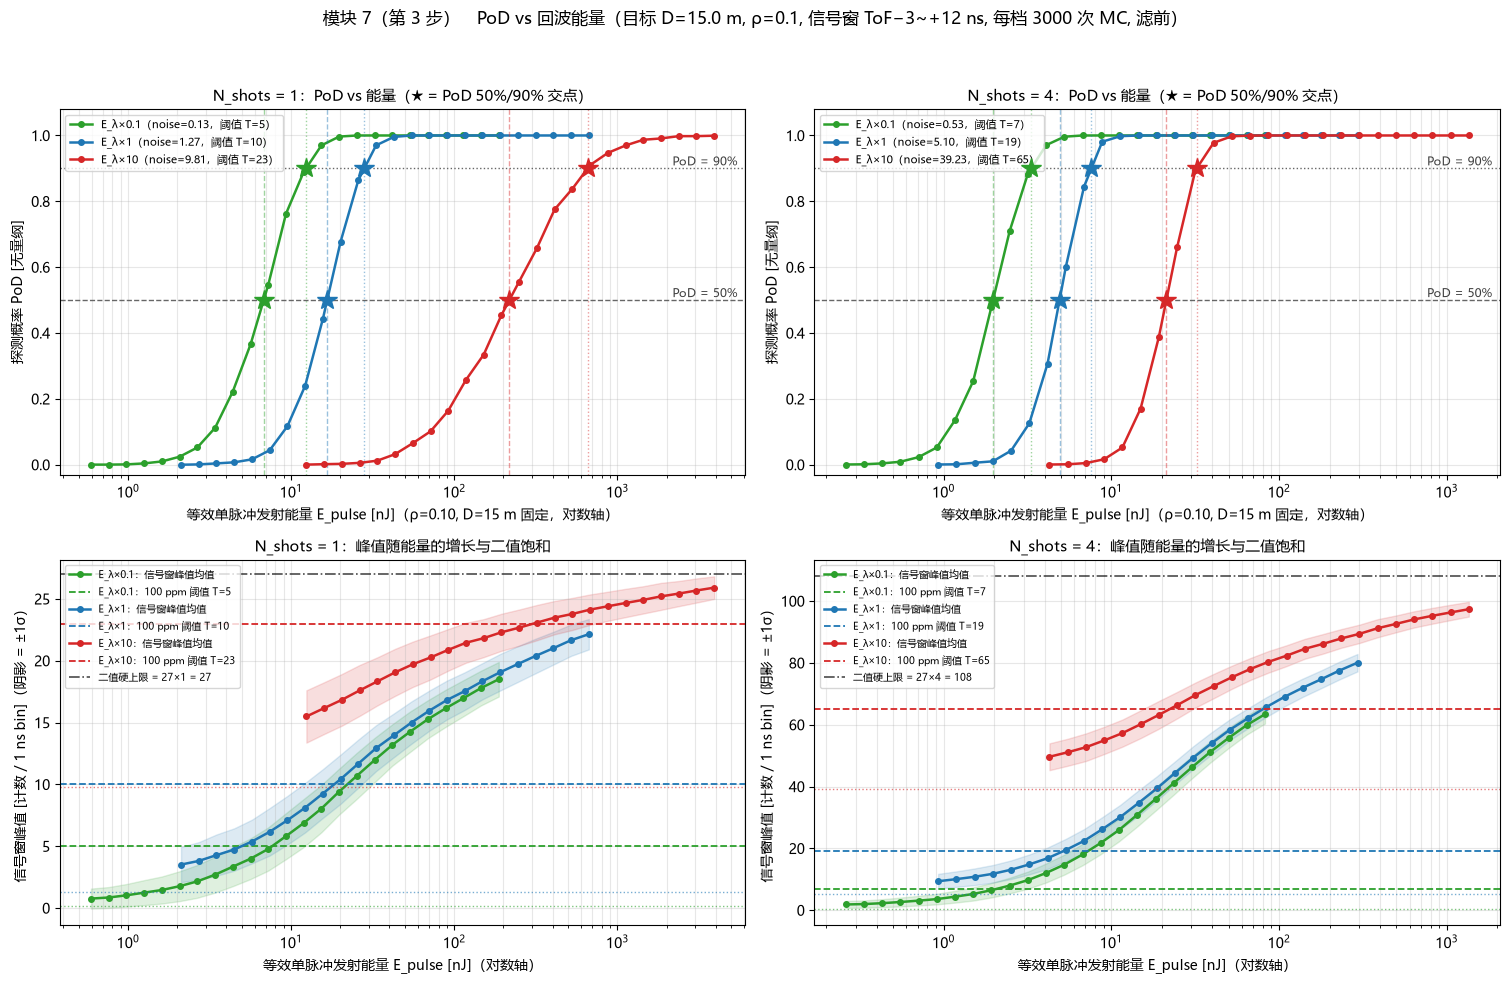

In [14]:
# ---- PoD 曲线图 ----
fig, axes = plt.subplots(2, len(N_SHOTS_LIST), figsize=(7.6*len(N_SHOTS_LIST), 10.0))
if len(N_SHOTS_LIST) == 1:
    axes = axes.reshape(2, 1)
_pc = {0.1: "tab:green", 1.0: "tab:blue", 10.0: "tab:red", 0.01: "tab:purple",
       0.03: "tab:cyan", 0.3: "tab:olive", 3.0: "tab:orange"}

for j, n_shots in enumerate(N_SHOTS_LIST):
    aT, aB = axes[0, j], axes[1, j]
    for mult in AMB_MULTS_POD:
        key = (n_shots, mult)
        if key not in POD_RES:
            continue
        r = POD_RES[key]
        E_nJ = r["boost"] * E_PULSE_BASE * 1e9
        c = _pc.get(mult, "k")
        aT.semilogx(E_nJ, r["pod"], "o-", color=c, lw=1.8, ms=4,
                    label=f"E_λ×{mult:g}（noise={r['noise']:.2f}，阈值 T={r['T']}）")
        for lv, ls in [(0.50, "--"), (0.90, ":")]:
            b = r["b50"] if lv == 0.50 else r["b90"]
            if np.isfinite(b):
                aT.plot([b*E_PULSE_BASE*1e9], [lv], "*", color=c, ms=15, zorder=6)
                aT.axvline(b*E_PULSE_BASE*1e9, color=c, ls=ls, lw=1.0, alpha=0.45)
        aB.semilogx(E_nJ, r["pmean"], "o-", color=c, lw=1.8, ms=4,
                    label=f"E_λ×{mult:g}：信号窗峰值均值")
        aB.fill_between(E_nJ, r["pmean"]-r["pstd"], r["pmean"]+r["pstd"],
                        color=c, alpha=0.15)
        aB.axhline(r["T"], color=c, ls="--", lw=1.3,
                   label=f"E_λ×{mult:g}：100 ppm 阈值 T={r['T']}")
        aB.axhline(r["noise"], color=c, ls=":", lw=1.0, alpha=0.6)
    aT.axhline(0.50, color="0.4", ls="--", lw=1.0)
    aT.axhline(0.90, color="0.4", ls=":", lw=1.0)
    aT.text(0.995, 0.50, "PoD = 50% ", fontsize=8.5, color="0.25", ha="right",
            va="bottom", transform=aT.get_yaxis_transform())
    aT.text(0.995, 0.90, "PoD = 90% ", fontsize=8.5, color="0.25", ha="right",
            va="bottom", transform=aT.get_yaxis_transform())
    aT.set_ylim(-0.03, 1.08)
    aT.set_xlabel("等效单脉冲发射能量 E_pulse [nJ]（ρ=0.10, D=15 m 固定，对数轴）")
    aT.set_ylabel("探测概率 PoD [无量纲]")
    aT.set_title(f"N_shots = {n_shots}：PoD vs 能量（★ = PoD 50%/90% 交点）", fontsize=11)
    aT.legend(fontsize=8, loc="upper left"); aT.grid(alpha=0.3, which="both")

    aB.axhline(N_PIX_MACRO*n_shots, color="k", ls="-.", lw=1.2, alpha=0.7,
               label=f"二值硬上限 = 27×{n_shots} = {N_PIX_MACRO*n_shots}")
    aB.set_xlabel("等效单脉冲发射能量 E_pulse [nJ]（对数轴）")
    aB.set_ylabel("信号窗峰值 [计数 / 1 ns bin]（阴影 = ±1σ）")
    aB.set_title(f"N_shots = {n_shots}：峰值随能量的增长与二值饱和", fontsize=11)
    aB.legend(fontsize=7.5, loc="upper left"); aB.grid(alpha=0.3, which="both")

plt.suptitle(f"模块 7（第 3 步）　PoD vs 回波能量（目标 D={D_TARGET} m, ρ={RHO_TARGET}, "
             f"信号窗 ToF−{SIG_PRE_NS:.0f}~+{SIG_POST_NS:.0f} ns, 每档 {N_MC_POD} 次 MC, 滤前）",
             fontsize=12.5)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("pod_esti_pod_curves.png", dpi=110, bbox_inches="tight")
plt.show()


## 模块 8 — 汇总：不同环境噪声下的阈值与 PoD 50% / 90% 能量

三种等价的「能量」度量（在固定 ρ = 0.10、D = 15 m 下）：

| 度量 | 含义 |
|---|---|
| `E_pulse` [nJ] | 等效单脉冲发射能量 = 799 nJ × boost（799 nJ 是当前 P_peak = 235 W 双指数脉冲的实际能量） |
| `ρ_eff` | 等效目标反射率 = 0.10 × boost（> 1 表示物理上要靠别的途径增强回波） |
| `N_ph` | 宏像元单 shot 入射的信号光子数 = boost × Σf_pix × ∫r_sig,unit dt |

另给出**等效最远探测距离**：把 PoD 所需的回波强度换算成「若发射能量与反射率都不变，
该强度对应多远的目标」，由

$$\frac{\mathrm{link}(D)}{\mathrm{link}(D_\mathrm{ref})}
=\left(\frac{D_\mathrm{ref}}{D}\right)^{2}e^{-2\alpha (D-D_\mathrm{ref})}=\mathrm{boost}$$

反解 $D$（$D_\mathrm{ref}=15$ m）。**boost 越小 ⇒ 允许的距离越远**，因为它意味着"回波再弱这么多倍仍能被探测到"。


【PoD_esti 汇总】目标 D=15.0 m, ρ=0.1, 宏像元 9×3=27 SPAD, 统计窗 152 bin, 噪点率目标 100 ppm
基准（boost=1）：E_pulse=799.4 nJ, ρ=0.10, 宏像元单 shot 信号光子数 N_ph=2165.58
------------------------------------------------------------------------------------------------------------------------------
N_shots  E_λ×   noise  σ_bin    T   上限   PoD      boost E_pulse[nJ]    ρ_eff     N_ph     等效距离[m]
------------------------------------------------------------------------------------------------------------------------------
      1   0.1   0.132  0.362    5   27   50% 8.4837e-03       6.782 0.000848     18.4       160.5
      1   0.1   0.132  0.362    5   27   90% 1.5415e-02       12.32  0.00154     33.4       119.6
      1     1   1.274  1.107   10   27   50% 2.0785e-02       16.62  0.00208       45       103.1
      1     1   1.274  1.107   10   27   90% 3.5109e-02       28.07  0.00351       76        79.5
      1    10   9.807  2.530   23   27   50% 2.7197e-01       217.4   0.0272      589        28.7
      1    10 

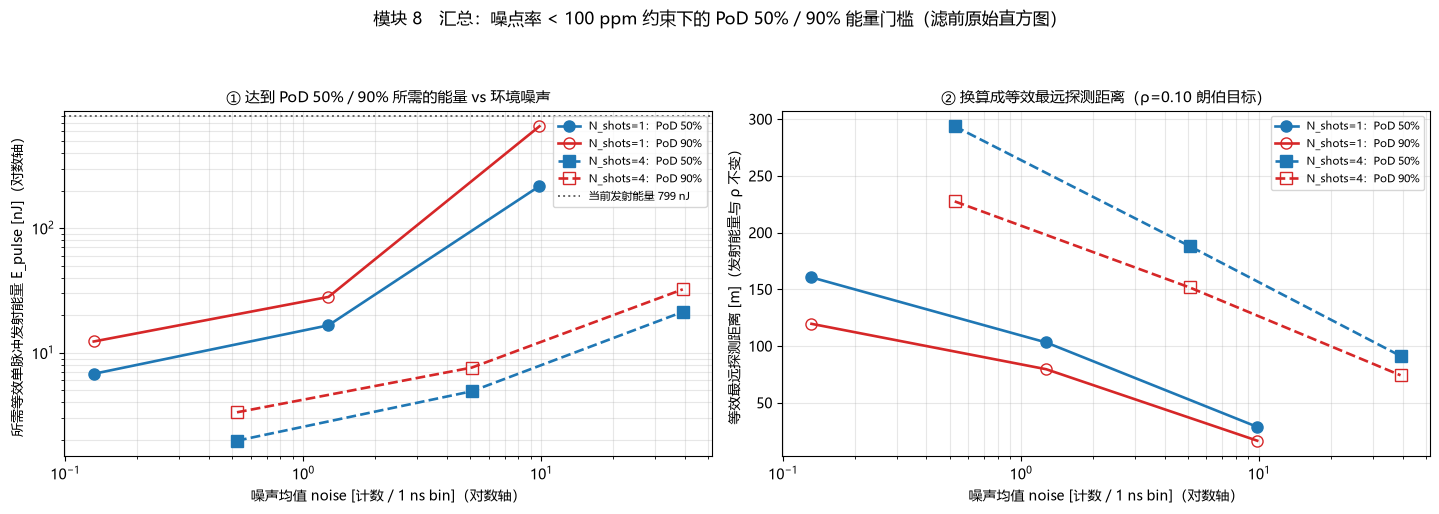

In [15]:
# 宏像元单 shot 入射信号光子数（boost=1，单位收集比例积分 × Σf_pix）
_NPH_BASE = np.trapezoid(R_SIG_UNIT_GEN, TF_GEN) * F_VALS.sum()

def equiv_distance(boost, D_ref=D_TARGET, p=PARAMS):
    """把能量倍数 boost 折成等效最远探测距离。

    boost < 1 表示"比 D_ref 处的实际回波弱 1/boost 倍仍能探测"，
    于是等效地：目标可以放到更远的 D，使回波衰减到同样水平：
        link(D) / link(D_ref) = (D_ref/D)²·exp(-2α(D-D_ref)) = boost
    boost 越小 → D 越大。
    """
    alpha = p["channel"]["alpha"]
    f = lambda D: (D_ref**2 / D**2) * np.exp(-2*alpha*(D - D_ref))
    Ds = np.logspace(np.log10(0.3), np.log10(5000.0), 6000)
    vals = f(Ds)                                   # 随 D 单调下降
    if boost > vals[0] or boost < vals[-1]:
        return np.nan
    return float(np.interp(-boost, -vals, Ds))     # 取负号把降序变升序

print("="*126)
print(f"【PoD_esti 汇总】目标 D={D_TARGET} m, ρ={RHO_TARGET}, 宏像元 {MACRO_BX}×{MACRO_BY}="
      f"{N_PIX_MACRO} SPAD, 统计窗 {N_STAT} bin, 噪点率目标 {TARGET_FAR*1e6:.0f} ppm")
print(f"基准（boost=1）：E_pulse={E_PULSE_BASE*1e9:.1f} nJ, ρ=0.10, "
      f"宏像元单 shot 信号光子数 N_ph={_NPH_BASE:.2f}")
print("-"*126)
hdr = (f"{'N_shots':>7}{'E_λ×':>6}{'noise':>8}{'σ_bin':>7}{'T':>5}{'上限':>5}"
       f"{'PoD':>6}{'boost':>11}{'E_pulse[nJ]':>12}{'ρ_eff':>9}{'N_ph':>9}{'等效距离[m]':>12}")
print(hdr); print("-"*126)
_rows = []
for n_shots in N_SHOTS_LIST:
    for mult in AMB_MULTS_POD:
        key = (n_shots, mult)
        if key not in POD_RES:
            continue
        r = POD_RES[key]
        for lv, b in [("50%", r["b50"]), ("90%", r["b90"])]:
            if not np.isfinite(b):
                print(f"{n_shots:>7d}{mult:>6g}{r['noise']:>8.3f}{r['sigma_bin']:>7.3f}"
                      f"{r['T']:>5d}{r['n_tr']:>5d}{lv:>6}{'未达到':>11}")
                continue
            E = b * E_PULSE_BASE * 1e9
            print(f"{n_shots:>7d}{mult:>6g}{r['noise']:>8.3f}{r['sigma_bin']:>7.3f}"
                  f"{r['T']:>5d}{r['n_tr']:>5d}{lv:>6}{b:>11.4e}{E:>12.4g}"
                  f"{RHO_TARGET*b:>9.3g}{_NPH_BASE*b:>9.3g}{equiv_distance(b):>12.1f}")
            _rows.append((n_shots, mult, lv, b, E, RHO_TARGET*b, _NPH_BASE*b))
print("-"*126)
print("说明：")
print("  · boost 是对【回波光子率】的线性倍数；在 ρ、D 固定时等价于把发射能量乘同样倍数。")
print("  · ρ_eff > 1 不代表不物理，只表示需要靠更高发射能量/更大口径/更近距离等其他途径达到同等回波。")
print("  · 等效距离 = 在发射能量与反射率都不变的前提下，该回波强度对应多远的目标"
      "（按 1/D²·exp(-2αD) 反解）。")

# ---- 汇总图 ----
fig, ax = plt.subplots(1, 2, figsize=(14.5, 5.2))
for n_shots, mk, ls in zip(N_SHOTS_LIST, ["o", "s"], ["-", "--"]):
    xs, y50, y90 = [], [], []
    for mult in AMB_MULTS_POD:
        key = (n_shots, mult)
        if key not in POD_RES:
            continue
        r = POD_RES[key]
        xs.append(r["noise"]); y50.append(r["b50"]*E_PULSE_BASE*1e9)
        y90.append(r["b90"]*E_PULSE_BASE*1e9)
    if not xs:
        continue
    ax[0].loglog(xs, y50, mk+ls, color="tab:blue", lw=1.9, ms=8,
                 label=f"N_shots={n_shots}：PoD 50%")
    ax[0].loglog(xs, y90, mk+ls, color="tab:red", lw=1.9, ms=8, mfc="none",
                 label=f"N_shots={n_shots}：PoD 90%")
ax[0].axhline(E_PULSE_BASE*1e9, color="0.4", ls=":", lw=1.4,
              label=f"当前发射能量 {E_PULSE_BASE*1e9:.0f} nJ")
ax[0].set_xlabel("噪声均值 noise [计数 / 1 ns bin]（对数轴）")
ax[0].set_ylabel("所需等效单脉冲发射能量 E_pulse [nJ]（对数轴）")
ax[0].set_title("① 达到 PoD 50% / 90% 所需的能量 vs 环境噪声", fontsize=11)
ax[0].legend(fontsize=8); ax[0].grid(alpha=0.3, which="both")

for n_shots, mk, ls in zip(N_SHOTS_LIST, ["o", "s"], ["-", "--"]):
    xs, d50, d90 = [], [], []
    for mult in AMB_MULTS_POD:
        key = (n_shots, mult)
        if key not in POD_RES:
            continue
        r = POD_RES[key]
        xs.append(r["noise"]); d50.append(equiv_distance(r["b50"]))
        d90.append(equiv_distance(r["b90"]))
    if not xs:
        continue
    ax[1].semilogx(xs, d50, mk+ls, color="tab:blue", lw=1.9, ms=8,
                   label=f"N_shots={n_shots}：PoD 50%")
    ax[1].semilogx(xs, d90, mk+ls, color="tab:red", lw=1.9, ms=8, mfc="none",
                   label=f"N_shots={n_shots}：PoD 90%")
ax[1].set_xlabel("噪声均值 noise [计数 / 1 ns bin]（对数轴）")
ax[1].set_ylabel("等效最远探测距离 [m]（发射能量与 ρ 不变）")
ax[1].set_title("② 换算成等效最远探测距离（ρ=0.10 朗伯目标）", fontsize=11)
ax[1].legend(fontsize=8); ax[1].grid(alpha=0.3, which="both")

plt.suptitle(f"模块 8　汇总：噪点率 < {TARGET_FAR*1e6:.0f} ppm 约束下的 PoD 50% / 90% 能量门槛（滤前原始直方图）",
             fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.savefig("pod_esti_summary.png", dpi=110, bbox_inches="tight")
plt.show()
